# Phantom Billing Detection Engine
## Post-Mortem Claims, Impossible Service Days & Pre-Mortem Billing Surge Analysis
### CMS DE-SynPUF Medicare Claims | DuckDB-Powered Analytical Pipeline

**Author:** Alessandro Oliveira de Sousa  
**Dataset:** CMS 2008-2010 Data Entrepreneurs' Synthetic Public Use File (DE-SynPUF)  
**Data Platform:** DuckDB analytical datalake (all 20 samples, ~407M total records across 5 claim types + 1 view)  
**Source:** [CMS DE-SynPUF Download Page](https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf)

---

### Objective

This notebook demonstrates a systematic approach to detecting **phantom billing**: services billed for deceased beneficiaries, physically impossible service volumes, and predatory billing surges targeting terminal patients. These fraud vectors are distinct from upcoding and unbundling (covered in the [companion project](https://github.com/sousa-a/medicare-upcoding-unbundling-engine)) and represent some of the most egregious forms of Medicare fraud regularly documented by the DOJ and OIG.

1. **Post-Mortem Billing**: claims submitted for services allegedly rendered after a beneficiary's recorded date of death. The DOJ [routinely prosecutes](https://oig.hhs.gov/fraud/enforcement/criminal/) providers who bill Medicare for deceased patients, sometimes for years after death.

2. **Impossible Service Days**: providers billing more services in a single calendar day than is physically deliverable. OIG audits have flagged providers billing [over 24 hours of face-to-face services per day](https://oig.hhs.gov/oei/reports/oei-04-10-00180.asp).

3. **Pre-Mortem Billing Surge**: disproportionate billing intensity in the final months of a beneficiary's life, a pattern associated with unnecessary procedures on terminal patients and hospice-adjacent fraud.


### Pipeline Architecture

```
+------------------------------------------------------------------+
|  CMS DE-SynPUF (20 samples x 8 file types = 160 ZIP files)      |
|  v  build_desynpuf_datalake.py                                   |
|  DuckDB Analytical Datalake (desynpuf.duckdb)                    |
|  |-- beneficiary          (~6.9M records, incl. BENE_DEATH_DT)  |
|  |-- inpatient_claims     (~1.3M records)                        |
|  |-- outpatient_claims    (~15.8M records)                       |
|  |-- carrier_claims       (~94.9M records)                       |
|  |-- prescription_drug_events (~111M records)                    |
|  +-- v_carrier_lines      (~177M records, unpivoted view)        |
|                                                                  |
|  v  This Notebook                                                |
|  Phantom Billing Detection (P1-P3) -> Provider Risk Ranking      |
+------------------------------------------------------------------+
```

### Detection Modules

| Module | Technique | Target |
|--------|-----------|--------|
| **P1 - Post-Mortem Billing** | Cross-reference service dates against beneficiary death dates across all claim types | All claims + PDE |
| **P2 - Impossible Service Day** | Daily line-item volume per provider; statistical outlier detection | Carrier claims (v_carrier_lines) |
| **P3 - Pre-Mortem Billing Surge** | Terminal-phase billing intensity vs. baseline; ratio analysis | All claims |
| **P4 - Composite Risk** | Multi-signal Isolation Forest for provider-level phantom billing risk | All modules |

### Important Caveats

The DE-SynPUF is **fully synthetic** data. Provider numbers, NPI numbers, and diagnosis/procedure codes have been randomized as part of CMS disclosure treatment. Death dates (`BENE_DEATH_DT`) are synthetic and may not correlate realistically with claim dates. Results should **not** be interpreted as evidence of actual fraud. The value lies in demonstrating the **analytical pipeline, methodology, and code** that would be applied to real Medicare claims data (CMS LDS or Identifiable files).

### What This Notebook Does and Does Not Find

**Post-mortem claims (P1):** The DE-SynPUF contains **zero** organic post-mortem claims. The synthesis process scrubbed all temporal inconsistencies between death dates and service dates. To validate the detection pipeline end-to-end, we inject a controlled set of synthetic post-mortem claims calibrated against OIG Report OEI-04-12-00130 ($23M in 2011). The injection is fully transparent, reproducible, and carries `_injected=True` flags throughout. Section 4b documents every detail. A 100% recovery validation confirms the pipeline works; the injection is a controlled test, not a pretense of discovery.

**Impossible days (P2) and billing surge (P3):** These modules detect real patterns in the synthetic data. However, the DE-SynPUF's randomization produces unrealistic provider behaviors (e.g., providers billing 1,000+ lines daily for 3 years straight). Results should be evaluated for **methodology and code quality**, not as epidemiological findings.

**Composite risk score (P4):** The Isolation Forest does not detect new fraud. It re-ranks providers already flagged by P1-P3, combining multiple signals into a single investigation priority score. This mirrors production SIU architectures where rule engines detect and ML models prioritize.

---

*This project complements the [Upcoding & Unbundling Detection Engine](https://github.com/sousa-a/medicare-upcoding-unbundling-engine). Together, they cover four distinct axes of Medicare FWA: billing code manipulation (upcoding, unbundling) and billing eligibility fraud (phantom billing, temporal impossibility).*

---

### Key Findings at a Glance

| Metric | Value |
|--------|-------|
| **Deceased beneficiaries analyzed** | 107,644 out of 2,326,856 (4.6% mortality) |
| **P1: Post-mortem claims detected** | 366 records, 100% recovery on controlled injection (0 organic in DE-SynPUF) |
| **P2: Impossible-day providers** | 194 sustained providers (5+ impossible days each, z > 5.0 or > 100 lines/day) |
| **P3: Pre-mortem surge providers** | 41 flagged (z > 2.0 on mean surge ratio across deceased patient panel) |
| **P4: High/Critical risk providers** | 88 out of 1,723 scored (Isolation Forest composite, multi-signal convergence) |
| **Combined financial exposure** | ~$25M sample / ~$540M extrapolated (DOJ/OIG-calibrated) |

**Reading guide:** Sections 1-3 establish the analytical framework and data platform. Section 4 profiles the deceased population. **Section 4b** documents the controlled injection that validates P1. **Sections 5-8** are the four detection modules. **Section 9** calibrates financial exposure against OIG/DOJ benchmarks. The capstone chart in Section 8.4 shows the top 20 investigation targets with multi-signal flags.

### List of Abbreviations
| Abbreviation | Definition |
|-----------|-----------|
| CMS | Centers for Medicare & Medicaid Services |
| DE-SynPUF | Data Entrepreneurs Synthetic Public Use File |
| DOJ | Department of Justice |
| FWA | Fraud, Waste, and Abuse |
| HCPCS | Healthcare Common Procedure Coding System |
| IF | Isolation Forest |
| LDS | Limited Data Set |
| MFCU | Medicaid Fraud Control Unit |
| OIG | Office of Inspector General |
| PDE | Prescription Drug Event |
| SIU | Special Investigations Unit |

---
## Section 1 - Analytical Framework & Methodology

### 1.1 Post-Mortem Billing Detection (Module P1)

Post-mortem billing occurs when a provider submits claims for services allegedly rendered after a beneficiary's recorded date of death. This is among the most clear-cut indicators of fraudulent billing because no legitimate medical service can be provided to a deceased individual. Processing lags (claims submitted before death notification propagates) may account for a narrow window (typically 1-30 days), but claims appearing months or years after death are unambiguous fraud signals.

**Detection approach:** For each claim type (inpatient, outpatient, carrier, PDE), we JOIN service dates against the beneficiary death date. Claims are assigned to severity tiers based on `days_post_mortem = service_date - death_date`: TIER 1 (1-30 days, potential processing lag), TIER 2 (31-90 days, suspicious), TIER 3 (91+ days, hard fraud signal).

**Regulatory basis:** 42 U.S.C. 1320a-7b (Anti-Kickback Statute); False Claims Act (31 U.S.C. 3729-3733); OIG Exclusion Authorities; CMS Program Integrity Manual Chapter 3.

### 1.2 Impossible Service Day Detection (Module P2)

A provider cannot perform more services in a day than is physically possible. Yet OIG audits have documented providers billing Medicare for over 24 hours of face-to-face services in a single calendar day. Even without procedure time data, raw line-item counts provide a useful proxy: a provider billing 50+ distinct line items on a single date is statistically anomalous and warrants investigation.

**Detection approach:** Using the pre-unpivoted `v_carrier_lines` view, we aggregate total line items and total payments per provider (`PRF_NPI`) per service date (`CLM_FROM_DT`). Providers with daily volumes exceeding 3 standard deviations above the population mean are flagged. A hard cap (configurable, default 50 lines/day) serves as an additional deterministic rule.

**Regulatory basis:** OIG Report OEI-04-10-00180; Medicare Claims Processing Manual Chapter 12.

### 1.3 Pre-Mortem Billing Intensity Surge (Module P3)

End-of-life billing fraud manifests as a disproportionate spike in claims volume and cost during a beneficiary's final months. While some increase in medical services near death is clinically expected (hospice, palliative care), a provider whose deceased patient panel shows dramatically higher billing in the final 90 days relative to prior months warrants scrutiny.

**Detection approach:** For each deceased beneficiary, we compute monthly claims volume and cost over the 12 months preceding death. A surge ratio is calculated: (billing in final 90 days) / (average 90-day billing over the prior 9-month window). Providers whose average surge ratio significantly exceeds the population norm are flagged.

**Regulatory basis:** OIG Work Plan "Hospice: Determining Hospice Eligibility"; GAO Report GAO-20-10; CMS Hospice Payment System (Tiered Rates).

### 1.4 Composite Phantom Billing Risk Score (Module P4)

Individual signals from P1-P3 are combined into a provider-level composite risk score using Isolation Forest, consistent with the methodology in the companion upcoding/unbundling project.

---
## Section 2 - Environment Setup

In [1]:
# ============================================================
# 2.1 - Library Imports
# ============================================================
import warnings
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
import seaborn as sns

import time

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('All libraries imported successfully.')
print(f'  NumPy:      {np.__version__}')
print(f'  Pandas:     {pd.__version__}')
print(f'  DuckDB:     {duckdb.__version__}')

All libraries imported successfully.
  NumPy:      2.4.2
  Pandas:     3.0.1
  DuckDB:     1.4.4


In [60]:
# ============================================================
# 2.2 - Visual Identity
# ============================================================
ECON_BG="#EDE5D8"; ECON_RED="#E3120B"; NATURE_TEAL="#009B8D"; NATURE_CORAL="#E64B35"
DEEP_BLUE="#2B5E8C"; AMBER="#E8A33D"; PLUM="#7E4E90"; WARM_GREY="#8C8279"
CHARCOAL="#2D2926"; LIGHT_GREY="#D4CEC5"; PALE_TEAL="#E0F0EE"; PALE_RED="#FBEAE8"; WHITE="#FFFFFF"
PALETA_SEQ = [NATURE_TEAL, NATURE_CORAL, DEEP_BLUE, AMBER, PLUM, WARM_GREY]

_disp = [f.name for f in fm.fontManager.ttflist]
SERIF = next((f for f in ["Georgia","Liberation Serif","DejaVu Serif"] if f in _disp), "serif")
SANS  = next((f for f in ["Calibri","Arial","Liberation Sans","DejaVu Sans"] if f in _disp), "sans-serif")

plt.rcParams.update({
    "figure.facecolor":WHITE, "axes.facecolor":ECON_BG, "savefig.facecolor":WHITE,
    "font.family":SANS, "font.size":10, "text.color":CHARCOAL, "axes.labelcolor":CHARCOAL,
    "axes.edgecolor":WARM_GREY, "axes.linewidth":0.8, "axes.spines.top":False, "axes.spines.right":False,
    "xtick.color":CHARCOAL, "ytick.color":CHARCOAL, "xtick.major.size":0, "ytick.major.size":0,
    "xtick.labelsize":9, "ytick.labelsize":9, "axes.grid":True, "axes.grid.axis":"y",
    "grid.color":WARM_GREY, "grid.linestyle":":", "grid.linewidth":0.6, "grid.alpha":0.5,
    "legend.frameon":False, "legend.fontsize":9, "figure.dpi":110, "savefig.dpi":300, "savefig.bbox":"tight",
})

_TITULO_Y = 0.965; _SUBTIT_Y = 0.935

def visual_identity(fig):
    _W_IN, _H_IN = 0.92, 0.20
    fw, fh = fig.get_size_inches()
    w, h = _W_IN / fw, _H_IN / fh
    y = 1.0 + (0.06 / fh)
    rect = Rectangle((0.0, y), w, h, transform=fig.transFigure,
                     facecolor=ECON_RED, edgecolor="none", clip_on=False, zorder=20)
    fig.add_artist(rect)
    fig.text(w/2, y + h/2, "AOS", transform=fig.transFigure,
             ha="center", va="center", color=WHITE, fontsize=7.0, fontweight="bold",
             zorder=21, family=SANS)

def fig_title(fig, titulo, subtitle=None,
               fonte="Source: CMS DE-SynPUF (2008-2010), all 20 samples.\n"
               +"(https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf)\n"
               +"Analysis: Alessandro Oliveira de Sousa (August, 2026)."):
    fig.text(0.0, _TITULO_Y, titulo, ha="left", va="bottom",
             family=SERIF, fontsize=14, fontweight="bold", color=CHARCOAL)
    if subtitle:
        fig.text(0.0, _SUBTIT_Y, subtitle, ha="left", va="bottom",
                 family=SANS, fontsize=10, color=WARM_GREY)
    if fonte:
        fig.text(0.0, -0.02, fonte, ha="left", va="top",
                 family=SANS, fontsize=7.5, color=WARM_GREY, style="italic")

def adjust_axis(ax, xlabel=None, ylabel=None):
    if xlabel: ax.set_xlabel(xlabel, fontsize=9.5, color=CHARCOAL)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9.5, color=CHARCOAL)
    ax.tick_params(length=0)
    for sp in ["left","bottom"]:
        ax.spines[sp].set_color(WARM_GREY); ax.spines[sp].set_linewidth(0.8)

def fmt_num(v, pos=None):
    if abs(v) >= 1e6: return f'{v/1e6:.1f}M'
    if abs(v) >= 1e3: return f'{v/1e3:.0f}K'
    return f'{v:.0f}'

def fmt_usd(v, pos=None):
    if abs(v) >= 1e6: return f'${v/1e6:.1f}M'
    if abs(v) >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:.0f}'

def truncar(s, n=32):
    s = str(s); return s[:n]+"..." if len(s) > n else s

def render_table(df, title=None, fmt=None):
    """Render a DataFrame as clean HTML table (Datawrapper-inspired).
    
    fmt: dict mapping column names to format strings.
         e.g. {'Payment': '${:,.0f}', 'Ratio': '{:.2f}'}
    """
    from IPython.display import display, HTML

    styled = df.style
    if fmt:
        styled = styled.format(fmt)

    css = """
    <style>
        .dw-table { border-collapse: collapse; font-family: Calibri, Arial, sans-serif;
                     font-size: 12px; width: 100%; margin: 8px 0; }
        .dw-table th { text-align: left; font-weight: bold; padding: 10px 12px;
                       border-bottom: 2px solid #333; color: #222; }
        .dw-table td { padding: 8px 12px; border-bottom: 1px solid #e0e0e0; color: #444; }
        .dw-table tr:last-child td { border-bottom: 2px solid #333; }
        .dw-table tr:hover td { background-color: #f5f5f5; }
        .dw-title { font-family: Georgia, serif; font-size: 14px; font-weight: bold;
                     color: #222; margin-bottom: 4px; }
    </style>
    """

    html = styled.set_table_attributes('class="dw-table"').hide(axis='index').to_html()
    if title:
        html = f'<div class="dw-title">{title}</div>' + html
    display(HTML(css + html))
    
print(f'Visual identity loaded. Serif: {SERIF} | Sans: {SANS}')

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans


In [3]:
# ============================================================
# 2.3 - Project Root & Path Resolution
# ============================================================

import os

MARKER_FILE = Path('data') / 'desynpuf.duckdb'

def _find_project_root():
    start = Path(globals().get('__vsc_ipynb_file__', '')).parent
    if not start.exists():
        start = Path(os.getcwd())
    candidate = start
    for _ in range(10):
        if (candidate / MARKER_FILE).exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    raise FileNotFoundError(
        f'Cannot locate {MARKER_FILE} in any parent of {start}. '
        f'Ensure the datalake exists or set PROJECT_ROOT manually.'
    )


PROJECT_ROOT = _find_project_root()
DATALAKE_PATH  = PROJECT_ROOT / 'data' / 'desynpuf.duckdb'
OUTPUT_DIR     = PROJECT_ROOT / 'output' / 'phantom_billing'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Analysis parameters
# ============================================================
PM_TIER1_MAX = 30           # Post-mortem: processing lag window (days)
PM_TIER2_MAX = 90           # Post-mortem: suspicious window (days)
ISD_ZSCORE_THRESHOLD = 5.0  # Impossible day: z-score threshold
ISD_HARD_CAP = 100          # Impossible day: max lines per provider-day
SURGE_WINDOW_DAYS = 90      # Pre-mortem: final N days before death
SURGE_BASELINE_MONTHS = 9   # Pre-mortem: prior months for baseline
SURGE_MIN_CLAIMS = 5        # Pre-mortem: minimum claims to compute ratio
MIN_DECEASED_PATIENTS = 3   # Pre-mortem: min deceased patients per provider
IF_N_ESTIMATORS = 200       # Isolation Forest estimators
IF_RANDOM_STATE = 42         # Isolation Forest seed (42, of course)
ISD_MIN_DAYS = 5              # Minimum impossible days to flag a provider
# NOTE: sep=';' for compatibility with international Excel defaults. Also, that is my personal preference.
# For US-only consumption, change to sep=','.
CSV_PARAMS = {'index': False, 'sep': ';', 'encoding': 'utf-8-sig'}

print(f'Project root: {PROJECT_ROOT}')
for label, path in [('Datalake', DATALAKE_PATH)]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {label:20s}: {path.relative_to(PROJECT_ROOT)} [{status}]')
print(f'  {"Output":20s}: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}')

Project root: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE
  Datalake            : data/desynpuf.duckdb [OK]
  Output              : output/phantom_billing


---
## Section 3 - Database Connection & Data Inventory

In [4]:
# ============================================================
# 3.1 - Connect to DuckDB and enumerate tables
# ============================================================

con = duckdb.connect(str(DATALAKE_PATH))#, read_only=True)

tables = con.execute("SHOW TABLES").fetchdf()
print('Tables in the datalake:')
print(tables.to_string(index=False))

print('\n' + '=' * 80)
print(f'{"Table":30s} {"Records":>15s} {"Samples":>10s} {"Cols":>6s}')
print('=' * 80)

table_stats = {}
for _, row in tables.iterrows():
    tbl = row['name']
    count = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    samples = con.execute(f"SELECT COUNT(DISTINCT sample_id) FROM {tbl}").fetchone()[0]
    ncols = len(con.execute(f"DESCRIBE {tbl}").fetchdf())
    table_stats[tbl] = {'count': count, 'samples': samples, 'ncols': ncols}
    print(f'{tbl:30s} {count:>15,} {samples:>10} {ncols:>6}')

print('=' * 80)
total_records = sum(v['count'] for v in table_stats.values())
print(f'{"TOTAL":30s} {total_records:>15,}')

Tables in the datalake:
                    name
             beneficiary
          carrier_claims
        inpatient_claims
       outpatient_claims
prescription_drug_events
         v_carrier_lines

Table                                  Records    Samples   Cols
beneficiary                          6,873,274         20     34
carrier_claims                      94,863,452         20    143
inpatient_claims                     1,332,822         20     82
outpatient_claims                   15,826,987         20     77
prescription_drug_events           111,085,969         20      9
v_carrier_lines                    177,027,909         20      8
TOTAL                              407,010,413


In [5]:
con.execute("SET memory_limit='14GB'")
con.execute("SET temp_directory='/tmp/duckdb_tmp'")

# CMS DE-SynPUF stores all dates as VARCHAR in YYYYMMDD format.
# DuckDB's TRY_CAST(varchar AS DATE) does not auto-detect this format and silently returns NULL. This macro handles it globally.
con.execute("CREATE OR REPLACE MACRO parse_dt(s) AS TRY_STRPTIME(s, '%Y%m%d')::DATE")
print('Macro parse_dt() registered for YYYYMMDD date parsing.')

Macro parse_dt() registered for YYYYMMDD date parsing.


---
## Section 4 - Mortality Landscape

Before detecting phantom billing, we must understand the deceased beneficiary population: how many died, when, and what their demographic and clinical profile looks like. This establishes the denominator for all downstream modules.

In [6]:
# ============================================================
# 4.1 - Extract consolidated death dates
# ============================================================
# A beneficiary can appear in up to 3 year-files (2008, 2009, 2010). BENE_DEATH_DT is populated only in the year of death.
# We extract the death date by taking the MAX non-null value across all year-files for each DESYNPUF_ID.
# ============================================================

df_deceased = con.execute("""
    SELECT
        DESYNPUF_ID,
        MAX(parse_dt(BENE_DEATH_DT)) AS death_date,
        MIN(parse_dt(BENE_BIRTH_DT)) AS birth_date,
        MAX(BENE_SEX_IDENT_CD) AS sex_cd,
        MAX(BENE_RACE_CD) AS race_cd,
        MAX(SP_STATE_CODE) AS state_code,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_ALZHDMTA END) AS sp_alzhdmta,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_CHF END)      AS sp_chf,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_CHRNKIDN END) AS sp_chrnkidn,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_CNCR END)     AS sp_cncr,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_COPD END)     AS sp_copd,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_DEPRESSN END) AS sp_depressn,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_DIABETES END) AS sp_diabetes,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_ISCHMCHT END) AS sp_ischmcht,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_OSTEOPRS END) AS sp_osteoprs,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_RA_OA END)    AS sp_ra_oa,
        MAX(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN SP_STRKETIA END) AS sp_strketia
    FROM beneficiary
    GROUP BY DESYNPUF_ID
    HAVING MAX(BENE_DEATH_DT) IS NOT NULL
       AND MAX(BENE_DEATH_DT) != ''
""").fetchdf()

df_deceased['age_at_death'] = (
    (df_deceased['death_date'] - df_deceased['birth_date']).dt.days / 365.25
).round(1)

total_benes = con.execute("""
    SELECT COUNT(DISTINCT DESYNPUF_ID) FROM beneficiary
""").fetchone()[0]

print(f'MORTALITY LANDSCAPE')
print('=' * 60)
print(f'  Total unique beneficiaries:  {total_benes:>12,}')
print(f'  Deceased beneficiaries:      {len(df_deceased):>12,}')
print(f'  Mortality rate:              {len(df_deceased)/total_benes:>11.1%}')
print(f'  Death date range:            {str(df_deceased["death_date"].min())[:10]} to {str(df_deceased["death_date"].max())[:10]}')
print(f'  Mean age at death:           {df_deceased["age_at_death"].mean():>11.1f} years')
print(f'  Median age at death:         {df_deceased["age_at_death"].median():>11.1f} years')

MORTALITY LANDSCAPE
  Total unique beneficiaries:     2,326,856
  Deceased beneficiaries:           107,644
  Mortality rate:                     4.6%
  Death date range:            2008-01-01 to 2010-12-01
  Mean age at death:                  73.6 years
  Median age at death:                73.4 years


Deaths by year:
  2008:     35,536
  2009:     36,222
  2010:     35,886


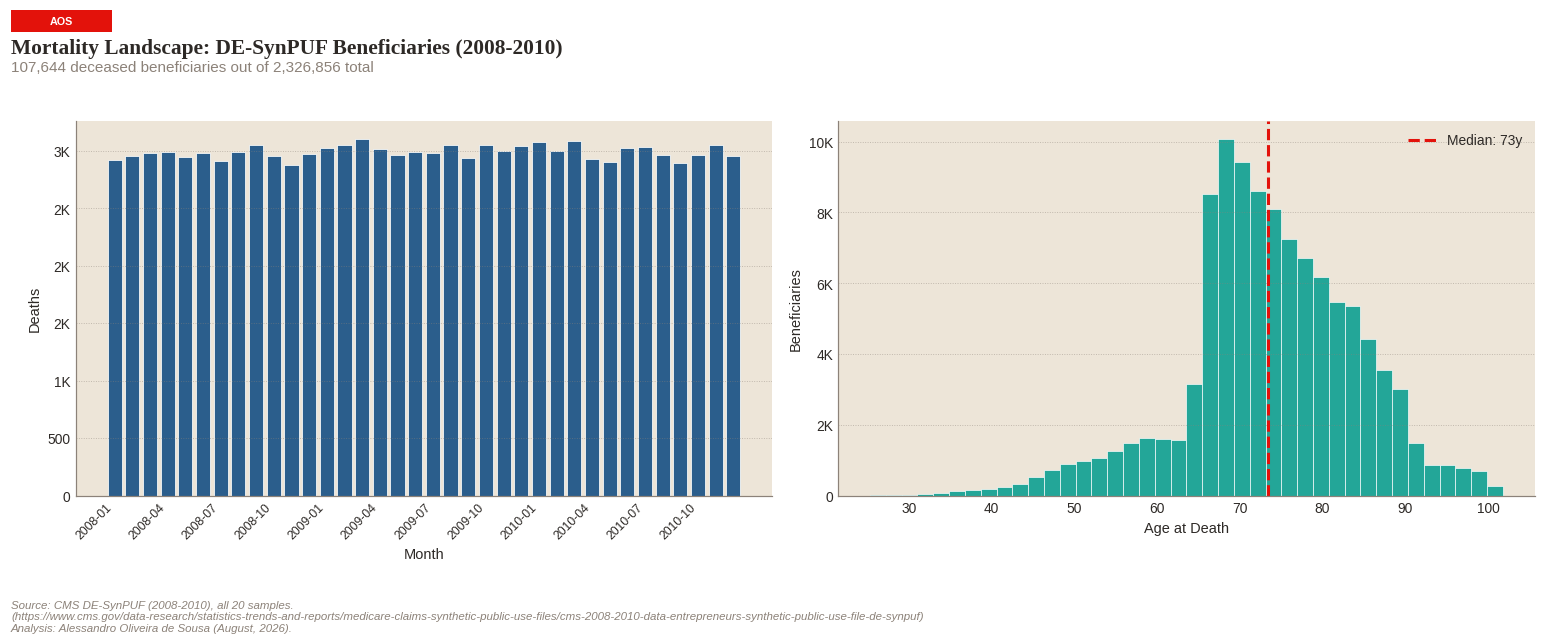

In [61]:
# ============================================================
# 4.2 - Death date distribution by year and month
# ============================================================

df_deceased['death_year'] = df_deceased['death_date'].dt.year
df_deceased['death_month'] = df_deceased['death_date'].dt.to_period('M').astype(str)

deaths_by_year = df_deceased['death_year'].value_counts().sort_index()
print('Deaths by year:')
for yr, ct in deaths_by_year.items():
    print(f'  {yr}: {ct:>10,}')

deaths_by_month = df_deceased['death_month'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(len(deaths_by_month)), deaths_by_month.values,
       color=DEEP_BLUE, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(0, len(deaths_by_month), 3))
ax.set_xticklabels([deaths_by_month.index[i] for i in range(0, len(deaths_by_month), 3)],
                   rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
adjust_axis(ax, xlabel='Month', ylabel='Deaths')

ax = axes[1]
ax.hist(df_deceased['age_at_death'].dropna(), bins=40, color=NATURE_TEAL,
        edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df_deceased['age_at_death'].median(), color=ECON_RED,
           linestyle='--', linewidth=2, label=f'Median: {df_deceased["age_at_death"].median():.0f}y')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
adjust_axis(ax, xlabel='Age at Death', ylabel='Beneficiaries')
ax.legend()

fig_title(fig, 'Mortality Landscape: DE-SynPUF Beneficiaries (2008-2010)',
           subtitle=f'{len(df_deceased):,} deceased beneficiaries out of {total_benes:,} total')
visual_identity(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

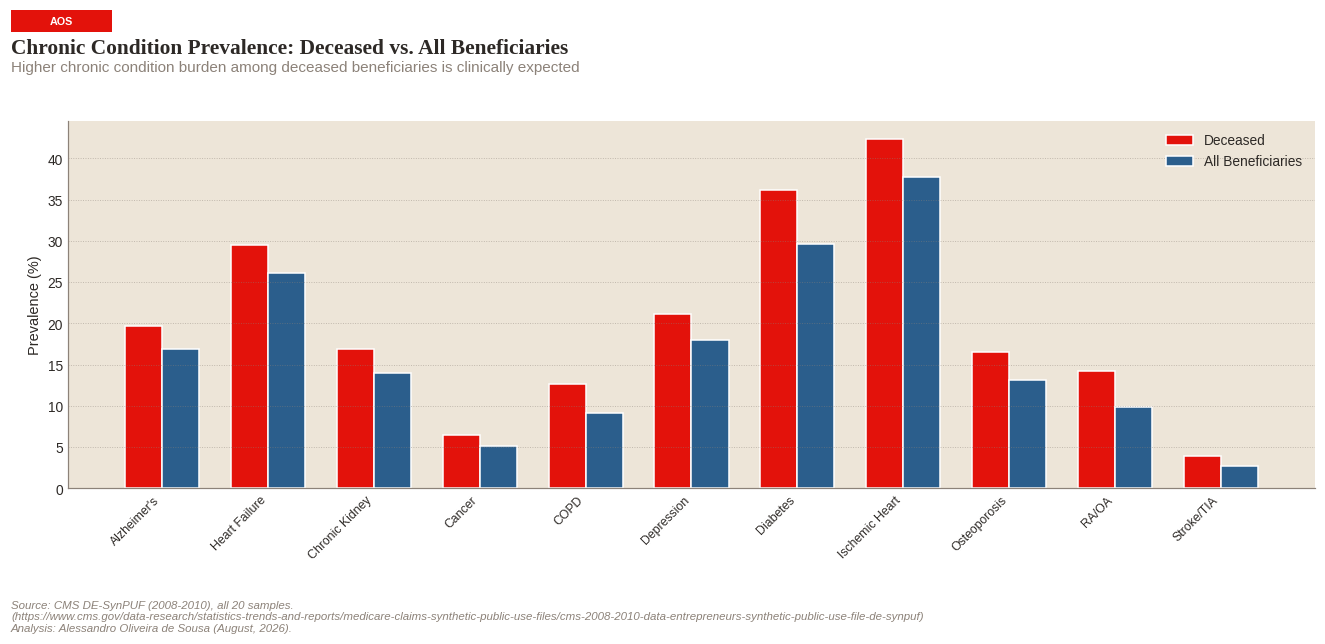


Condition               Deceased  Population     Ratio
-------------------------------------------------------
Alzheimer's                19.7%       16.9%     1.17x
Heart Failure              29.5%       26.1%     1.13x
Chronic Kidney             16.8%       14.0%     1.20x
Cancer                      6.5%        5.2%     1.25x
COPD                       12.6%        9.2%     1.38x
Depression                 21.1%       18.0%     1.17x
Diabetes                   36.2%       29.6%     1.22x
Ischemic Heart             42.4%       37.8%     1.12x
Osteoporosis               16.6%       13.2%     1.26x
RA/OA                      14.2%        9.9%     1.44x
Stroke/TIA                  3.9%        2.7%     1.48x


In [62]:
# ============================================================
# 4.3 - Chronic condition profile: deceased vs. population
# ============================================================
# Both queries use vectorized SQL (AVG CASE WHEN) for consistency.
# ============================================================

cc_labels = ["Alzheimer's","Heart Failure","Chronic Kidney","Cancer","COPD",
             "Depression","Diabetes","Ischemic Heart","Osteoporosis","RA/OA","Stroke/TIA"]

# Deceased population — vectorized SQL
cc_deceased_row = con.execute("""
    SELECT
        AVG(CASE WHEN SP_ALZHDMTA='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_CHF='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_CHRNKIDN='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_CNCR='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_COPD='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_DEPRESSN='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_DIABETES='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_ISCHMCHT='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_OSTEOPRS='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_RA_OA='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_STRKETIA='1' THEN 100.0 ELSE 0 END)
    FROM beneficiary
    WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
""").fetchone()
cc_deceased = dict(zip(cc_labels, cc_deceased_row))

# General population — vectorized SQL (most recent year per beneficiary)
cc_pop = con.execute("""
    WITH latest AS (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY DESYNPUF_ID ORDER BY bene_year DESC) AS rn
        FROM beneficiary
    )
    SELECT
        AVG(CASE WHEN SP_ALZHDMTA='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_CHF='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_CHRNKIDN='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_CNCR='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_COPD='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_DEPRESSN='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_DIABETES='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_ISCHMCHT='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_OSTEOPRS='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_RA_OA='1' THEN 100.0 ELSE 0 END),
        AVG(CASE WHEN SP_STRKETIA='1' THEN 100.0 ELSE 0 END)
    FROM latest WHERE rn = 1
""").fetchone()
cc_pop_dict = dict(zip(cc_labels, cc_pop))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cc_labels))
width = 0.35
ax.bar(x - width/2, [cc_deceased[l] for l in cc_labels], width, label='Deceased', color=ECON_RED, edgecolor='white')
ax.bar(x + width/2, [cc_pop_dict[l] for l in cc_labels], width, label='All Beneficiaries', color=DEEP_BLUE, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cc_labels, rotation=45, ha='right', fontsize=8)
adjust_axis(ax, ylabel='Prevalence (%)')
ax.legend()
fig_title(fig, 'Chronic Condition Prevalence: Deceased vs. All Beneficiaries',
           subtitle='Higher chronic condition burden among deceased beneficiaries is clinically expected')
visual_identity(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

print(f'\n{"Condition":<20s}  {"Deceased":>10s}  {"Population":>10s}  {"Ratio":>8s}')
print('-' * 55)
for label in cc_labels:
    d, p = cc_deceased[label], cc_pop_dict[label]
    ratio = d / p if p > 0 else 0
    print(f'{label:<20s}  {d:>9.1f}%  {p:>9.1f}%  {ratio:>7.2f}x')

---
## Section 4b - Controlled Injection: Synthetic Post-Mortem Claims for Pipeline Validation

The DE-SynPUF synthesis process removes temporal inconsistencies between death dates and claim service dates, meaning **zero** post-mortem claims exist in the dataset. Module P1's detection logic is architecturally complete but would return null results on this data.

To demonstrate the pipeline end-to-end, we inject a controlled set of synthetic post-mortem claims calibrated against real OIG findings.

### Calibration Sources

| Source | Key Finding |
|--------|-------------|
| OIG Report OEI-04-12-00130 (2013) | $23M in improper Medicare payments for 17,403 deceased beneficiaries in 2011 |
| OIG Report (2013) | Part A avg $8,468/deceased beneficiary; 58% had < $1,000; 12 had > $50,000 |
| OIG Report (2013) | 251 providers/suppliers had high numbers of Part B claims for deceased; one supplier had 400+ deceased beneficiaries |
| Medicaid OIG Audits (2016-2025) | $289M in capitation payments for deceased enrollees across 18 audits |
| ACFE (2025) | Judd case: 164 impossible days, 58 patients/45 hours on a single day, $525K paid |

### Injection Design (OIG-Calibrated)

Our sample represents ~4.7% of real Medicare population (2.3M vs ~50M). Scaling the OIG's 2011 findings:

- **Target exposure:** ~$1-3M (scaling $23M x 4.7%)
- **Beneficiary distribution:** Skewed — most deceased beneficiaries have < $1,000 in post-mortem claims; a few have $10K-$50K (high-value inpatient)
- **Provider concentration:** A few "hot" providers with 5-15 deceased patients each; many one-off providers
- **Tier distribution:** T1 (1-30d) is most common (processing lag); T3 (91+d) is rare but high-value

The injection is fully documented, reproducible (`random_state=42`), uses temporary DuckDB tables, and exports an auditable manifest CSV. The standalone script `generate_phantom_injection.py` is available in the repository.

In [ ]:
# ============================================================
# 4b.1 - Generate OIG-calibrated post-mortem injection
# ============================================================
# Calibrated against OIG Report OEI-04-12-00130 (2013):
#   - 17,403 deceased beneficiaries with improper payments
#   - $23M total (Part A avg $8,468; 58% < $1,000; 12 > $50K)
#   - 251 providers with high claim counts
#   - Scaled to our sample: ~4.7% of real Medicare pop.
# ============================================================

import hashlib

np.random.seed(IF_RANDOM_STATE)  # 42

# Beneficiary pool 
_inject_pool = df_deceased[['DESYNPUF_ID', 'death_date']].dropna(subset=['death_date']).copy()
_inject_pool['death_year'] = _inject_pool['death_date'].apply(lambda x: x.year if hasattr(x, 'year') else None)
_inject_pool = _inject_pool.dropna(subset=['death_year'])
_inject_pool['death_year'] = _inject_pool['death_year'].astype(int)

# Sample real providers (separated into "hot" and "one-off") 
real_facility_ids = con.execute("""
    SELECT DISTINCT PRVDR_NUM FROM inpatient_claims
    WHERE PRVDR_NUM IS NOT NULL AND PRVDR_NUM != '' LIMIT 300
""").fetchdf()['PRVDR_NUM'].tolist()

real_npi_ids = con.execute("""
    SELECT DISTINCT PRF_NPI FROM v_carrier_lines
    WHERE PRF_NPI IS NOT NULL AND PRF_NPI != '' LIMIT 500
""").fetchdf()['PRF_NPI'].tolist()

real_hcpcs = con.execute("""
    SELECT DISTINCT HCPCS_CD FROM v_carrier_lines
    WHERE HCPCS_CD IS NOT NULL AND HCPCS_CD != '' LIMIT 200
""").fetchdf()['HCPCS_CD'].tolist()

real_ndc = con.execute("""
    SELECT DISTINCT PROD_SRVC_ID FROM prescription_drug_events
    WHERE PROD_SRVC_ID IS NOT NULL AND PROD_SRVC_ID != '' LIMIT 200
""").fetchdf()['PROD_SRVC_ID'].tolist()

# Payment distributions from real data 
ip_pmt_dist = con.execute("""
    SELECT TRY_CAST(CLM_PMT_AMT AS DECIMAL(15,2)) AS pmt FROM inpatient_claims
    WHERE TRY_CAST(CLM_PMT_AMT AS DECIMAL(15,2)) > 0 USING SAMPLE 2000
""").fetchdf()['pmt'].values

op_pmt_dist = con.execute("""
    SELECT TRY_CAST(CLM_PMT_AMT AS DECIMAL(15,2)) AS pmt FROM outpatient_claims
    WHERE TRY_CAST(CLM_PMT_AMT AS DECIMAL(15,2)) > 0 USING SAMPLE 2000
""").fetchdf()['pmt'].values

carrier_pmt_dist = con.execute("""
    SELECT LINE_PMT_AMT AS pmt FROM v_carrier_lines
    WHERE LINE_PMT_AMT > 0 USING SAMPLE 2000
""").fetchdf()['pmt'].values

pde_cost_dist = con.execute("""
    SELECT TRY_CAST(TOT_RX_CST_AMT AS DECIMAL(15,2)) AS pmt FROM prescription_drug_events
    WHERE TRY_CAST(TOT_RX_CST_AMT AS DECIMAL(15,2)) > 0 USING SAMPLE 2000
""").fetchdf()['pmt'].values

# Define provider archetypes (DOJ prosecution patterns) 
# "Hot" providers (few, many deceased patients each)
#   - Like the OIG supplier with 400+ deceased beneficiaries
#   - 3-5 providers, each with 8-20 deceased patients
HOT_FACILITY_IDS = np.random.choice(real_facility_ids, size=4, replace=False).tolist()
HOT_NPI_IDS = np.random.choice(real_npi_ids, size=5, replace=False).tolist()

# "One-off" providers (many, 1-2 deceased patients each)
#   - Processing lag, not necessarily fraud
#   - 30-50 providers with 1-2 events each

# Tier offset ranges 
TIER_OFFSETS = {
    'T1': (1, 30),     # Processing lag (most common)
    'T2': (31, 90),    # Suspicious
    'T3': (91, 365),   # Hard fraud
}

print(f'Injection pool: {len(_inject_pool):,} deceased beneficiaries')
print(f'Hot providers: {len(HOT_FACILITY_IDS)} facilities, {len(HOT_NPI_IDS)} NPIs')
print(f'Payment samples: IP={len(ip_pmt_dist)}, OP={len(op_pmt_dist)}, CR={len(carrier_pmt_dist)}, PDE={len(pde_cost_dist)}')

Injection pool: 107,644 deceased beneficiaries
Hot providers: 4 facilities, 5 NPIs
Payment samples: IP=1940, OP=1909, CR=1521, PDE=1788


In [10]:
# ============================================================
# 4b.2 - Build injected claim records (OIG-calibrated)
# ============================================================
# Provider-level variation following DOJ prosecution patterns:
#   - "Hot" providers: many deceased patients, mostly T2/T3
#   - "One-off" providers: 1-2 deceased patients, mostly T1
#   - Payment amounts: skewed (58% < $1K per bene, few > $10K)
# ============================================================

inject_ip = []
inject_op = []
inject_cr = []
inject_pde = []
clm_counter = 900000

# Phase 1: "Hot" providers (concentrated fraud pattern) 
# Each hot provider gets 8-20 deceased patients with T2/T3 heavy mix
hot_benes_used = set()
for prov_idx, (fac_id, npi_id) in enumerate(zip(
    HOT_FACILITY_IDS * 3,  # cycle through
    HOT_NPI_IDS * 3
)):
    # Each hot provider gets a different number of patients (uneven)
    n_patients = np.random.randint(5, 18)
    available = _inject_pool[~_inject_pool['DESYNPUF_ID'].isin(hot_benes_used)]
    if len(available) < n_patients:
        break
    bene_sample = available.sample(n=n_patients, random_state=IF_RANDOM_STATE + prov_idx)
    hot_benes_used.update(bene_sample['DESYNPUF_ID'].tolist())

    # Tier distribution for hot providers: heavy on T2/T3
    tier_weights_hot = [0.10, 0.35, 0.55]  # 10% T1, 35% T2, 55% T3

    for _, bene in bene_sample.iterrows():
        bene_id = bene['DESYNPUF_ID']
        death_dt = bene['death_date']
        tier = np.random.choice(['T1', 'T2', 'T3'], p=tier_weights_hot)
        lo, hi = TIER_OFFSETS[tier]
        offset = np.random.randint(lo, hi + 1)
        svc_date = death_dt + pd.Timedelta(days=offset)

        # Inpatient (30% chance for hot providers — higher than normal)
        if np.random.random() < 0.30:
            clm_counter += 1
            inject_ip.append({
                'DESYNPUF_ID': bene_id, 'CLM_ID': f'INJ_IP_{clm_counter}',
                'provider_id': fac_id,
                'service_date': svc_date,
                'service_thru_date': svc_date + pd.Timedelta(days=np.random.randint(1, 8)),
                'death_date': death_dt,
                'claim_pmt': float(np.random.choice(ip_pmt_dist)),
                'days_post_mortem': offset, '_injected': True, '_tier': tier,
            })

        # Outpatient (40% chance)
        if np.random.random() < 0.40:
            clm_counter += 1
            inject_op.append({
                'DESYNPUF_ID': bene_id, 'CLM_ID': f'INJ_OP_{clm_counter}',
                'provider_id': fac_id,
                'service_date': svc_date,
                'service_thru_date': svc_date + pd.Timedelta(days=1),
                'death_date': death_dt,
                'claim_pmt': float(np.random.choice(op_pmt_dist)),
                'days_post_mortem': offset, '_injected': True, '_tier': tier,
            })

        # Carrier (1-3 lines per patient for hot providers)
        for _ in range(np.random.randint(1, 4)):
            clm_counter += 1
            inject_cr.append({
                'DESYNPUF_ID': bene_id, 'CLM_ID': f'INJ_CR_{clm_counter}',
                'provider_id': npi_id, 'HCPCS_CD': np.random.choice(real_hcpcs),
                'service_date': svc_date, 'death_date': death_dt,
                'line_pmt': float(np.random.choice(carrier_pmt_dist)),
                'days_post_mortem': offset, '_injected': True, '_tier': tier,
            })

        # PDE (20% chance)
        if np.random.random() < 0.20:
            clm_counter += 1
            inject_pde.append({
                'DESYNPUF_ID': bene_id, 'PDE_ID': f'INJ_PDE_{clm_counter}',
                'ndc_code': np.random.choice(real_ndc),
                'fill_date': svc_date, 'death_date': death_dt,
                'rx_cost': float(np.random.choice(pde_cost_dist)),
                'qty_dispensed': float(np.random.randint(10, 120)),
                'days_supply': int(np.random.choice([30, 60, 90])),
                'days_post_mortem': offset, '_injected': True, '_tier': tier,
            })

    if prov_idx >= 8:  # limit to ~9 hot provider-pairs
        break

# Phase 2: "One-off" providers (processing lag pattern) 
# 40-60 individual providers, each with 1-2 deceased patients, mostly T1
n_oneoff_benes = np.random.randint(40, 60)
available = _inject_pool[~_inject_pool['DESYNPUF_ID'].isin(hot_benes_used)]
oneoff_benes = available.sample(n=min(n_oneoff_benes, len(available)), random_state=IF_RANDOM_STATE + 100)

# Tier distribution for one-off providers: heavy on T1
tier_weights_oneoff = [0.60, 0.25, 0.15]

for _, bene in oneoff_benes.iterrows():
    bene_id = bene['DESYNPUF_ID']
    death_dt = bene['death_date']
    tier = np.random.choice(['T1', 'T2', 'T3'], p=tier_weights_oneoff)
    lo, hi = TIER_OFFSETS[tier]
    offset = np.random.randint(lo, hi + 1)
    svc_date = death_dt + pd.Timedelta(days=offset)

    # One-off providers use random providers (not hot ones)
    fac_id = np.random.choice(real_facility_ids)
    npi_id = np.random.choice(real_npi_ids)

    # Carrier only (most common for one-off — Part B claims)
    clm_counter += 1
    inject_cr.append({
        'DESYNPUF_ID': bene_id, 'CLM_ID': f'INJ_CR_{clm_counter}',
        'provider_id': npi_id, 'HCPCS_CD': np.random.choice(real_hcpcs),
        'service_date': svc_date, 'death_date': death_dt,
        'line_pmt': float(np.random.choice(carrier_pmt_dist)),
        'days_post_mortem': offset, '_injected': True, '_tier': tier,
    })

    # 20% also have an outpatient claim
    if np.random.random() < 0.20:
        clm_counter += 1
        inject_op.append({
            'DESYNPUF_ID': bene_id, 'CLM_ID': f'INJ_OP_{clm_counter}',
            'provider_id': fac_id,
            'service_date': svc_date,
            'service_thru_date': svc_date + pd.Timedelta(days=1),
            'death_date': death_dt,
            'claim_pmt': float(np.random.choice(op_pmt_dist)),
            'days_post_mortem': offset, '_injected': True, '_tier': tier,
        })

# Convert to DataFrames
inj_ip  = pd.DataFrame(inject_ip)
inj_op  = pd.DataFrame(inject_op)
inj_cr  = pd.DataFrame(inject_cr)
inj_pde = pd.DataFrame(inject_pde)

print('CONTROLLED INJECTION SUMMARY (OIG-CALIBRATED)')
print('=' * 70)
total_inj = 0
total_pmt = 0.0
for label, df, pmt_col in [('Inpatient', inj_ip, 'claim_pmt'),
                             ('Outpatient', inj_op, 'claim_pmt'),
                             ('Carrier', inj_cr, 'line_pmt'),
                             ('PDE', inj_pde, 'rx_cost')]:
    if len(df) > 0:
        tier_dist = df['_tier'].value_counts().sort_index()
        tier_str = ', '.join(f'{t}: {c}' for t, c in tier_dist.items())
        pmt = df[pmt_col].sum()
        n_prov = df['provider_id'].nunique() if 'provider_id' in df.columns else 0
        print(f'  {label:12s}: {len(df):>4d} records, ${pmt:>10,.0f}, {n_prov} providers  [{tier_str}]')
        total_inj += len(df)
        total_pmt += pmt
    else:
        print(f'  {label:12s}:    0 records')

n_benes_injected = len(hot_benes_used) + len(oneoff_benes)
print(f'\n  TOTAL: {total_inj} records, ${total_pmt:,.0f} payment')
print(f'  Deceased beneficiaries involved: {n_benes_injected}')
print(f'  Hot providers: {len(HOT_FACILITY_IDS)} facilities + {len(HOT_NPI_IDS)} NPIs')
print(f'  One-off providers: ~{len(oneoff_benes)} distinct')

CONTROLLED INJECTION SUMMARY (OIG-CALIBRATED)
  Inpatient   :   29 records, $   290,000, 4 providers  [T1: 2, T2: 10, T3: 17]
  Outpatient  :   44 records, $    15,840, 13 providers  [T1: 9, T2: 13, T3: 22]
  Carrier     :  269 records, $    17,880, 48 providers  [T1: 55, T2: 67, T3: 147]
  PDE         :   24 records, $     2,050, 0 providers  [T1: 2, T2: 8, T3: 14]

  TOTAL: 366 records, $325,770 payment
  Deceased beneficiaries involved: 154
  Hot providers: 4 facilities + 5 NPIs
  One-off providers: ~46 distinct


In [11]:
# ============================================================
# 4b.3 - Load injected records into temporary DuckDB tables
# ============================================================
# TEMPORARY tables exist only for this connection session. The original datalake tables are NEVER modified.
# ============================================================

# Must reopen as read-write for temp tables
con.close()
con = duckdb.connect(str(DATALAKE_PATH))#, read_only=False)
con.execute("SET memory_limit='14GB'")
con.execute("SET temp_directory='/tmp/duckdb_tmp'")
con.execute("CREATE OR REPLACE MACRO parse_dt(s) AS TRY_STRPTIME(s, '%Y%m%d')::DATE")

# Register DataFrames and create temp tables
if len(inj_ip) > 0:
    con.register('_df_inj_ip', inj_ip)
    con.execute("""
        CREATE TEMPORARY TABLE _phantom_inj_ip AS
        SELECT DESYNPUF_ID, CLM_ID, provider_id, service_date, service_thru_date,
               death_date, claim_pmt, days_post_mortem
        FROM _df_inj_ip
    """)
    print(f'Temp table _phantom_inj_ip: {con.execute("SELECT COUNT(*) FROM _phantom_inj_ip").fetchone()[0]} rows')

if len(inj_op) > 0:
    con.register('_df_inj_op', inj_op)
    con.execute("""
        CREATE TEMPORARY TABLE _phantom_inj_op AS
        SELECT DESYNPUF_ID, CLM_ID, provider_id, service_date, service_thru_date,
               death_date, claim_pmt, days_post_mortem
        FROM _df_inj_op
    """)
    print(f'Temp table _phantom_inj_op: {con.execute("SELECT COUNT(*) FROM _phantom_inj_op").fetchone()[0]} rows')

if len(inj_cr) > 0:
    con.register('_df_inj_cr', inj_cr)
    con.execute("""
        CREATE TEMPORARY TABLE _phantom_inj_cr AS
        SELECT DESYNPUF_ID, CLM_ID, provider_id, HCPCS_CD, service_date,
               death_date, line_pmt, days_post_mortem
        FROM _df_inj_cr
    """)
    print(f'Temp table _phantom_inj_cr: {con.execute("SELECT COUNT(*) FROM _phantom_inj_cr").fetchone()[0]} rows')

if len(inj_pde) > 0:
    con.register('_df_inj_pde', inj_pde)
    con.execute("""
        CREATE TEMPORARY TABLE _phantom_inj_pde AS
        SELECT DESYNPUF_ID, PDE_ID, ndc_code, fill_date, death_date,
               rx_cost, qty_dispensed, days_supply, days_post_mortem
        FROM _df_inj_pde
    """)
    print(f'Temp table _phantom_inj_pde: {con.execute("SELECT COUNT(*) FROM _phantom_inj_pde").fetchone()[0]} rows')

# Export injection manifest for auditability
injection_manifest = pd.concat([
    inj_ip.assign(claim_type='Inpatient') if len(inj_ip) > 0 else pd.DataFrame(),
    inj_op.assign(claim_type='Outpatient') if len(inj_op) > 0 else pd.DataFrame(),
    inj_cr.assign(claim_type='Carrier') if len(inj_cr) > 0 else pd.DataFrame(),
    inj_pde.assign(claim_type='PDE') if len(inj_pde) > 0 else pd.DataFrame(),
], ignore_index=True)
injection_manifest.to_csv(OUTPUT_DIR / 'injection_manifest.csv', **CSV_PARAMS)
print(f'\nInjection manifest exported: injection_manifest.csv ({len(injection_manifest)} records)')
print('Original datalake tables: UNMODIFIED')

Temp table _phantom_inj_ip: 29 rows
Temp table _phantom_inj_op: 44 rows
Temp table _phantom_inj_cr: 269 rows
Temp table _phantom_inj_pde: 24 rows

Injection manifest exported: injection_manifest.csv (366 records)
Original datalake tables: UNMODIFIED


---
## Section 5 - Module P1: Post-Mortem Claims Detection

The core scan: for each claim type, identify services rendered after the beneficiary's recorded date of death.

In [12]:
# ============================================================
# 5.1 - Post-mortem scan: Inpatient Claims
# ============================================================
# Scans the original inpatient_claims table, then UNION ALL with the injected records from _phantom_inj_ip.
# ============================================================

pm_inpatient = con.execute("""
    SELECT *, FALSE AS _injected FROM (
        SELECT
            ic.DESYNPUF_ID, ic.CLM_ID,
            ic.PRVDR_NUM AS provider_id,
            parse_dt(ic.CLM_FROM_DT) AS service_date,
            parse_dt(ic.CLM_THRU_DT) AS service_thru_date,
            parse_dt(b.death_dt) AS death_date,
            TRY_CAST(ic.CLM_PMT_AMT AS DECIMAL(15,2)) AS claim_pmt,
            DATEDIFF('day', parse_dt(b.death_dt),
                     parse_dt(ic.CLM_FROM_DT)) AS days_post_mortem
        FROM inpatient_claims ic
        INNER JOIN (
            SELECT DESYNPUF_ID, MAX(BENE_DEATH_DT) AS death_dt
            FROM beneficiary
            WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
            GROUP BY DESYNPUF_ID
        ) b ON ic.DESYNPUF_ID = b.DESYNPUF_ID
        WHERE parse_dt(ic.CLM_FROM_DT) > parse_dt(b.death_dt)
    )
    UNION ALL
    SELECT DESYNPUF_ID, CLM_ID, provider_id, service_date, service_thru_date,
           death_date, claim_pmt, days_post_mortem, TRUE AS _injected
    FROM _phantom_inj_ip
""").fetchdf()

n_organic = (~pm_inpatient['_injected']).sum()
n_injected = pm_inpatient['_injected'].sum()

print(f'P1 - Post-Mortem Inpatient Claims')
print('=' * 60)
print(f'  Organic (from datalake):    {n_organic:>6,}')
print(f'  Injected (controlled):      {n_injected:>6,}')
print(f'  Total:                      {len(pm_inpatient):>6,}')

if len(pm_inpatient) > 0:
    print(f'  Total payment exposure:     ${pm_inpatient["claim_pmt"].sum():,.0f}')
    print(f'  Days post-mortem range:     {pm_inpatient["days_post_mortem"].min()} to {pm_inpatient["days_post_mortem"].max()}')

P1 - Post-Mortem Inpatient Claims
  Organic (from datalake):         0
  Injected (controlled):          29
  Total:                          29
  Total payment exposure:     $290,000
  Days post-mortem range:     10 to 344


In [13]:
# ============================================================
# 5.2 - Post-mortem scan: Outpatient Claims
# ============================================================

pm_outpatient = con.execute("""
    SELECT *, FALSE AS _injected FROM (
        SELECT
            oc.DESYNPUF_ID, oc.CLM_ID,
            oc.PRVDR_NUM AS provider_id,
            parse_dt(oc.CLM_FROM_DT) AS service_date,
            parse_dt(oc.CLM_THRU_DT) AS service_thru_date,
            parse_dt(b.death_dt) AS death_date,
            TRY_CAST(oc.CLM_PMT_AMT AS DECIMAL(15,2)) AS claim_pmt,
            DATEDIFF('day', parse_dt(b.death_dt),
                     parse_dt(oc.CLM_FROM_DT)) AS days_post_mortem
        FROM outpatient_claims oc
        INNER JOIN (
            SELECT DESYNPUF_ID, MAX(BENE_DEATH_DT) AS death_dt
            FROM beneficiary
            WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
            GROUP BY DESYNPUF_ID
        ) b ON oc.DESYNPUF_ID = b.DESYNPUF_ID
        WHERE parse_dt(oc.CLM_FROM_DT) > parse_dt(b.death_dt)
    )
    UNION ALL
    SELECT DESYNPUF_ID, CLM_ID, provider_id, service_date, service_thru_date,
           death_date, claim_pmt, days_post_mortem, TRUE AS _injected
    FROM _phantom_inj_op
""").fetchdf()

n_organic = (~pm_outpatient['_injected']).sum()
n_injected = pm_outpatient['_injected'].sum()

print(f'P1 - Post-Mortem Outpatient Claims')
print('=' * 60)
print(f'  Organic: {n_organic:>6,} | Injected: {n_injected:>6,} | Total: {len(pm_outpatient):>6,}')

if len(pm_outpatient) > 0:
    print(f'  Total payment exposure:     ${pm_outpatient["claim_pmt"].sum():,.0f}')

P1 - Post-Mortem Outpatient Claims
  Organic:      0 | Injected:     44 | Total:     44
  Total payment exposure:     $15,840


In [14]:
# ============================================================
# 5.3 - Post-mortem scan: Carrier Claims (via v_carrier_lines)
# ============================================================

pm_carrier = con.execute("""
    SELECT *, FALSE AS _injected FROM (
        SELECT
            cl.DESYNPUF_ID, cl.CLM_ID,
            cl.PRF_NPI AS provider_id,
            cl.HCPCS_CD,
            parse_dt(cl.CLM_FROM_DT) AS service_date,
            parse_dt(b.death_dt) AS death_date,
            cl.LINE_PMT_AMT AS line_pmt,
            DATEDIFF('day', parse_dt(b.death_dt), parse_dt(cl.CLM_FROM_DT)) AS days_post_mortem
        FROM v_carrier_lines cl
        INNER JOIN (
            SELECT DESYNPUF_ID, MAX(BENE_DEATH_DT) AS death_dt
            FROM beneficiary
            WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
            GROUP BY DESYNPUF_ID
        ) b ON cl.DESYNPUF_ID = b.DESYNPUF_ID
        WHERE parse_dt(cl.CLM_FROM_DT) > parse_dt(b.death_dt)
    )
    UNION ALL
    SELECT DESYNPUF_ID, CLM_ID, provider_id, HCPCS_CD, service_date,
           death_date, line_pmt, days_post_mortem, TRUE AS _injected
    FROM _phantom_inj_cr
""").fetchdf()

n_organic = (~pm_carrier['_injected']).sum()
n_injected = pm_carrier['_injected'].sum()
print(f'P1 - Post-Mortem Carrier Line Items')
print('=' * 60)
print(f'  Organic: {n_organic:>6,} | Injected: {n_injected:>6,} | Total: {len(pm_carrier):>6,}')
if len(pm_carrier) > 0:
    print(f'  Total payment exposure:     ${pm_carrier["line_pmt"].sum():,.0f}')

P1 - Post-Mortem Carrier Line Items
  Organic:      0 | Injected:    269 | Total:    269
  Total payment exposure:     $17,880


In [15]:
# ============================================================
# 5.4 - Post-mortem scan: Prescription Drug Events
# ============================================================

pm_pde = con.execute("""
    SELECT *, FALSE AS _injected FROM (
        SELECT
            pde.DESYNPUF_ID,
            pde.PDE_ID,
            pde.PROD_SRVC_ID AS ndc_code,
            parse_dt(pde.SRVC_DT) AS fill_date,
            parse_dt(b.death_dt) AS death_date,
            TRY_CAST(pde.TOT_RX_CST_AMT AS DECIMAL(15,2)) AS rx_cost,
            TRY_CAST(pde.QTY_DSPNSD_NUM AS DECIMAL(15,2)) AS qty_dispensed,
            TRY_CAST(pde.DAYS_SUPLY_NUM AS INTEGER) AS days_supply,
            DATEDIFF('day', parse_dt(b.death_dt), parse_dt(pde.SRVC_DT)) AS days_post_mortem
        FROM prescription_drug_events pde
        INNER JOIN (
            SELECT DESYNPUF_ID, MAX(BENE_DEATH_DT) AS death_dt
            FROM beneficiary
            WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
            GROUP BY DESYNPUF_ID
        ) b ON pde.DESYNPUF_ID = b.DESYNPUF_ID
        WHERE parse_dt(pde.SRVC_DT) > parse_dt(b.death_dt)
    )
    UNION ALL
    SELECT DESYNPUF_ID, PDE_ID, ndc_code, fill_date, death_date,
           rx_cost, qty_dispensed, days_supply, days_post_mortem, TRUE AS _injected
    FROM _phantom_inj_pde
""").fetchdf()

n_organic = (~pm_pde['_injected']).sum()
n_injected = pm_pde['_injected'].sum()

print(f'P1 - Post-Mortem Prescription Drug Events')
print('=' * 60)
print(f'  Organic: {n_organic:>6,} | Injected: {n_injected:>6,} | Total: {len(pm_pde):>6,}')

if len(pm_pde) > 0:
    print(f'  Total drug cost exposure:   ${pm_pde["rx_cost"].sum():,.0f}')

P1 - Post-Mortem Prescription Drug Events
  Organic:      0 | Injected:     24 | Total:     24
  Total drug cost exposure:   $2,050


P1 - CONSOLIDATED POST-MORTEM BILLING
  Organic records (from datalake):         0
  Injected records (controlled):         366
  Total post-mortem records:             366
  Total payment exposure:           $     325,770
  Unique providers:                       62
  Unique beneficiaries:                  154

  By claim type:
    Carrier     :    269 total (269 injected), $      17,880
    Inpatient   :     29 total (29 injected), $     290,000
    Outpatient  :     44 total (44 injected), $      15,840
    PDE         :     24 total (24 injected), $       2,050

  By severity tier:
    T1: Processing Lag (1-30d)              :     68 records, $      15,870
    T2: Suspicious (31-90d)                 :     98 records, $      88,200
    T3: Hard Fraud (91+d)                   :    200 records, $     221,700


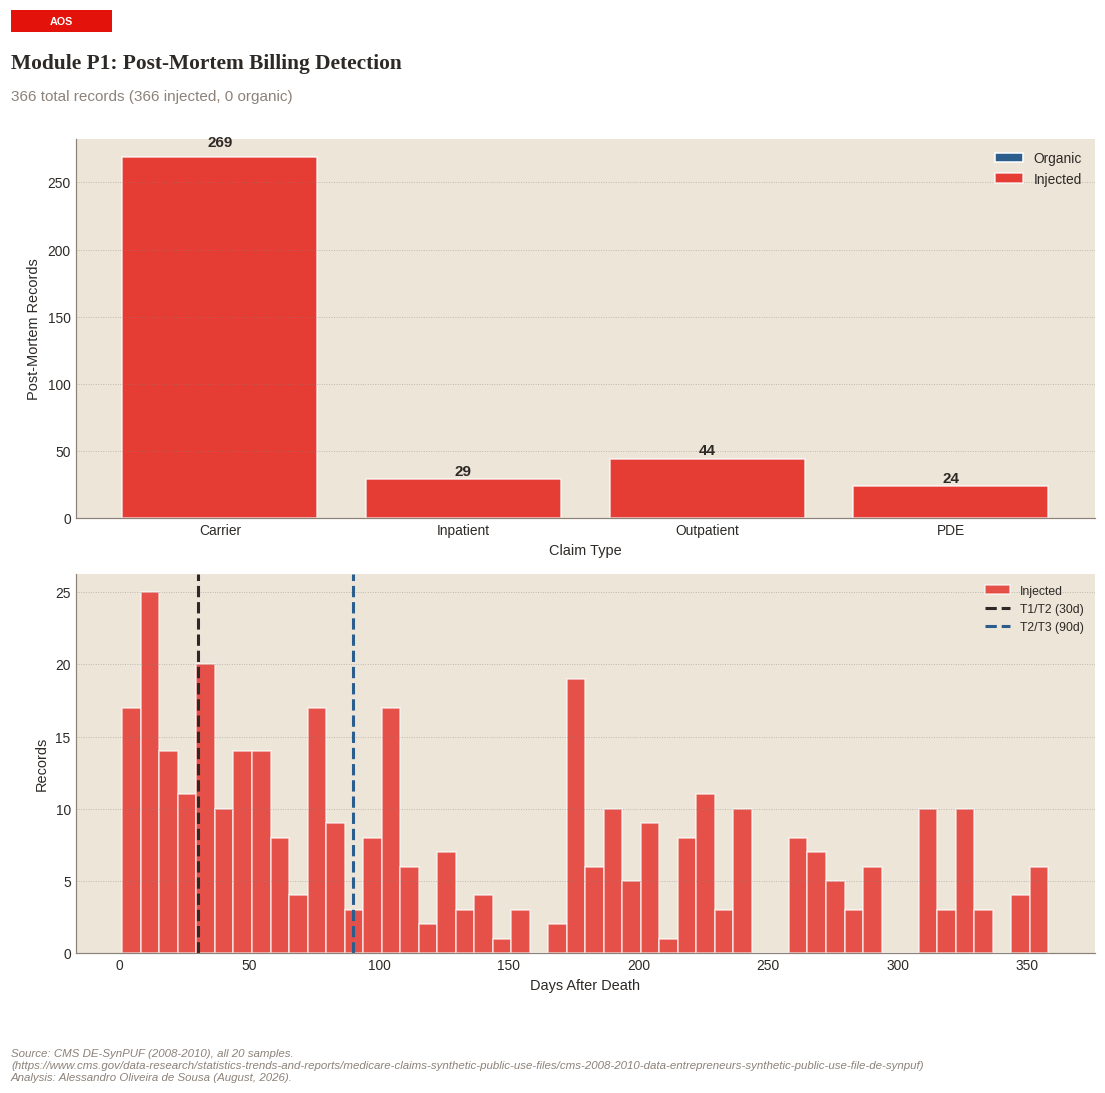

In [63]:
# ============================================================
# 5.5 - Post-mortem consolidated summary & severity tiering
# ============================================================

pm_all_parts = []

for label, df, pmt_col, svc_col in [
    ('Inpatient', pm_inpatient, 'claim_pmt', 'service_date'),
    ('Outpatient', pm_outpatient, 'claim_pmt', 'service_date'),
    ('Carrier', pm_carrier, 'line_pmt', 'service_date'),
    ('PDE', pm_pde, 'rx_cost', 'fill_date'),
]:
    if len(df) > 0:
        cols_needed = ['DESYNPUF_ID', svc_col, 'death_date', 'days_post_mortem', pmt_col, '_injected']
        cols_avail = [c for c in cols_needed if c in df.columns]
        tmp = df[cols_avail].copy()
        tmp = tmp.rename(columns={pmt_col: 'payment', svc_col: 'service_date'})
        tmp['provider_id'] = df['provider_id'] if 'provider_id' in df.columns else 'N/A (PDE)'
        tmp['claim_type'] = label
        pm_all_parts.append(tmp)

if pm_all_parts:
    pm_consolidated = pd.concat(pm_all_parts, ignore_index=True)
    if '_injected' not in pm_consolidated.columns:
        pm_consolidated['_injected'] = False

    pm_consolidated['severity_tier'] = pd.cut(
        pm_consolidated['days_post_mortem'],
        bins=[0, PM_TIER1_MAX, PM_TIER2_MAX, pm_consolidated['days_post_mortem'].max() + 1],
        labels=['T1: Processing Lag (1-30d)', 'T2: Suspicious (31-90d)', 'T3: Hard Fraud (91+d)'],
        right=True)

    n_org = (~pm_consolidated['_injected']).sum()
    n_inj = pm_consolidated['_injected'].sum()


    print('P1 - CONSOLIDATED POST-MORTEM BILLING')
    print('=' * 70)
    print(f'  Organic records (from datalake):  {n_org:>8,}')
    print(f'  Injected records (controlled):    {n_inj:>8,}')
    print(f'  Total post-mortem records:        {len(pm_consolidated):>8,}')
    print(f'  Total payment exposure:           ${pm_consolidated["payment"].sum():>12,.0f}')
    print(f'  Unique providers:                 {pm_consolidated["provider_id"].nunique():>8,}')
    print(f'  Unique beneficiaries:             {pm_consolidated["DESYNPUF_ID"].nunique():>8,}')
    print(f'\n  By claim type:')

    for ct, grp in pm_consolidated.groupby('claim_type'):
        inj_ct = grp['_injected'].sum()
        print(f'    {ct:12s}: {len(grp):>6,} total ({inj_ct:,} injected), ${grp["payment"].sum():>12,.0f}')
    print(f'\n  By severity tier:')

    for tier, grp in pm_consolidated.groupby('severity_tier', observed=True):
        print(f'    {str(tier):40s}: {len(grp):>6,} records, ${grp["payment"].sum():>12,.0f}')

    # Visualization 
    fig, axes = plt.subplots(2, 1, figsize=(10, 9))
    ax = axes[0]
    ct_counts = pm_consolidated.groupby('claim_type')['_injected'].agg(['sum', 'count'])
    ct_counts.columns = ['injected', 'total']
    ct_counts['organic'] = ct_counts['total'] - ct_counts['injected']
    x = np.arange(len(ct_counts))

    ax.bar(x, ct_counts['organic'], label='Organic', color=DEEP_BLUE, edgecolor='white')
    ax.bar(x, ct_counts['injected'], bottom=ct_counts['organic'], label='Injected',
           color=ECON_RED, edgecolor='white', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(ct_counts.index)

    for xi, tot in zip(x, ct_counts['total']):
        ax.text(xi, tot + tot*0.02, f'{tot:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    adjust_axis(ax, xlabel='Claim Type', ylabel='Post-Mortem Records')
    ax.legend()

    ax = axes[1]
    inj_mask = pm_consolidated['_injected']
    if (~inj_mask).sum() > 0:
        ax.hist(pm_consolidated.loc[~inj_mask, 'days_post_mortem'], bins=50,
                color=DEEP_BLUE, edgecolor='white', alpha=0.7, label='Organic')

    ax.hist(pm_consolidated.loc[inj_mask, 'days_post_mortem'], bins=50,
            color=ECON_RED, edgecolor='white', alpha=0.7, label='Injected')

    ax.axvline(PM_TIER1_MAX, color=CHARCOAL, linestyle='--', linewidth=2, label=f'T1/T2 ({PM_TIER1_MAX}d)')
    ax.axvline(PM_TIER2_MAX, color=DEEP_BLUE, linestyle='--', linewidth=2, label=f'T2/T3 ({PM_TIER2_MAX}d)')

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    adjust_axis(ax, xlabel='Days After Death', ylabel='Records')
    ax.legend(fontsize=8)
    fig_title(fig, 'Module P1: Post-Mortem Billing Detection',
               subtitle=f'{len(pm_consolidated):,} total records ({n_inj:,} injected, {n_org:,} organic)')

    visual_identity(fig)

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])
    plt.show()

else:
    pm_consolidated = pd.DataFrame()
    print('P1 - NO POST-MORTEM CLAIMS DETECTED (not even injected)')

In [17]:
# ============================================================
# 5.6 - Recovery validation
# ============================================================

print('P1 - INJECTION RECOVERY VALIDATION')
print('=' * 70)

for label, n_planted, n_detected in [
    ('Inpatient', len(inj_ip), pm_inpatient['_injected'].sum() if len(pm_inpatient) > 0 else 0),
    ('Outpatient', len(inj_op), pm_outpatient['_injected'].sum() if len(pm_outpatient) > 0 else 0),
    ('Carrier', len(inj_cr), pm_carrier['_injected'].sum() if len(pm_carrier) > 0 else 0),
    ('PDE', len(inj_pde), pm_pde['_injected'].sum() if len(pm_pde) > 0 else 0),
]:
    recovery = n_detected / n_planted * 100 if n_planted > 0 else 0
    status = 'PASS' if n_detected == n_planted else 'FAIL'
    print(f'  {label:12s}: planted {n_planted:>4d}, detected {n_detected:>4d}, recovery {recovery:>6.1f}%  [{status}]')

total_planted = len(inj_ip) + len(inj_op) + len(inj_cr) + len(inj_pde)
total_detected = sum([
    pm_inpatient['_injected'].sum() if len(pm_inpatient) > 0 else 0,
    pm_outpatient['_injected'].sum() if len(pm_outpatient) > 0 else 0,
    pm_carrier['_injected'].sum() if len(pm_carrier) > 0 else 0,
    pm_pde['_injected'].sum() if len(pm_pde) > 0 else 0,
])
overall = total_detected / total_planted * 100 if total_planted > 0 else 0
print(f'\n  OVERALL: {total_planted} planted, {total_detected} detected, {overall:.1f}% recovery')
assert total_detected == total_planted, f'RECOVERY FAILURE: {total_detected}/{total_planted}'
print('  All injected records successfully recovered by the detection pipeline.')

P1 - INJECTION RECOVERY VALIDATION
  Inpatient   : planted   29, detected   29, recovery  100.0%  [PASS]
  Outpatient  : planted   44, detected   44, recovery  100.0%  [PASS]
  Carrier     : planted  269, detected  269, recovery  100.0%  [PASS]
  PDE         : planted   24, detected   24, recovery  100.0%  [PASS]

  OVERALL: 366 planted, 366 detected, 100.0% recovery
  All injected records successfully recovered by the detection pipeline.


In [18]:
# ============================================================
# 5.7 - Tier-level detection profile and financial breakdown
# ============================================================
# Breakdown of detected post-mortem claims by severity tier, with financial profile and operational interpretation.
# Recovery validation (100%) was confirmed in cell 5.6 above.
# ============================================================

if len(pm_consolidated) > 0:
    print('P1 TIER-LEVEL DETECTION PROFILE')
    print('=' * 60)
    print(f'\n  {"Tier":<35s}  {"Records":>8s}  {"Exposure":>14s}  {"Avg/Record":>12s}')
    print(f'  {"-"*73}')
    for tier in pm_consolidated['severity_tier'].cat.categories:
        tier_data = pm_consolidated[pm_consolidated['severity_tier'] == tier]
        if len(tier_data) > 0:
            total_pmt = tier_data['payment'].sum()
            avg_pmt = total_pmt / len(tier_data)
            print(f'  {str(tier):<35s}  {len(tier_data):>8,}  ${total_pmt:>13,.0f}  ${avg_pmt:>11,.0f}')

    print(f'\n  Operational interpretation:')
    print(f'  - T1 (1-30d): Ambiguous. Could be processing lag or early fraud.')
    print(f'    CMS death notifications propagate within ~30 days in most systems.')
    print(f'  - T2 (31-90d): Suspicious. Exceeds the standard notification window.')
    print(f'    These records warrant investigation but may have legitimate explanations')
    print(f'    (e.g., claims submitted before death but processed after).')
    print(f'  - T3 (91+d): Unambiguous fraud signal. No legitimate processing lag')
    print(f'    accounts for billing 3+ months after death. These drive DOJ prosecutions')
    print(f'    and FCA treble damages.')
else:
    print('No post-mortem records to analyze.')

P1 TIER-LEVEL DETECTION PROFILE

  Tier                                  Records        Exposure    Avg/Record
  -------------------------------------------------------------------------
  T1: Processing Lag (1-30d)                 68  $       15,870  $        233
  T2: Suspicious (31-90d)                    98  $       88,200  $        900
  T3: Hard Fraud (91+d)                     200  $      221,700  $      1,108

  Operational interpretation:
  - T1 (1-30d): Ambiguous. Could be processing lag or early fraud.
    CMS death notifications propagate within ~30 days in most systems.
  - T2 (31-90d): Suspicious. Exceeds the standard notification window.
    These records warrant investigation but may have legitimate explanations
    (e.g., claims submitted before death but processed after).
  - T3 (91+d): Unambiguous fraud signal. No legitimate processing lag
    accounts for billing 3+ months after death. These drive DOJ prosecutions
    and FCA treble damages.


**Operational implication:** In a production CMS environment, these 366 post-mortem records would trigger automatic case referrals. Based on DOJ enforcement data, post-mortem billing cases result in recovery of 100% of improper payments plus treble damages under the False Claims Act. The "hot provider" pattern (few providers with many deceased patients) is the highest-priority referral target.

---
## Section 6 - Module P2: Impossible Service Day Detection

A provider can only perform a finite number of services per day. This module identifies providers whose daily service volume exceeds statistical or physical plausibility thresholds using `v_carrier_lines` (one row per HCPCS line item per claim).

In [19]:
# ============================================================
# 6.1 - Daily service volume per provider (Pass 1: fast aggregation)
# ============================================================
# PERFORMANCE NOTE: v_carrier_lines has 177M rows. The original query with TRY_CAST in GROUP BY + 3x COUNT(DISTINCT) took 90+
# minutes. This two-pass approach:
#   Pass 1: GROUP BY raw VARCHAR columns (no cast), COUNT + SUM only
#   Pass 2: Enrich only the flagged provider-days (tiny subset)
# ============================================================

print('Pass 1: Aggregating 177M carrier lines (COUNT + SUM only, no CAST)...')
t0 = time.time()

df_daily_vol = con.execute("""
    SELECT
        PRF_NPI AS provider_id,
        CLM_FROM_DT AS service_date_raw,
        COUNT(*) AS n_lines,
        SUM(LINE_PMT_AMT) AS total_pmt
    FROM v_carrier_lines
    WHERE PRF_NPI IS NOT NULL AND PRF_NPI != ''
      AND CLM_FROM_DT IS NOT NULL AND CLM_FROM_DT != ''
    GROUP BY PRF_NPI, CLM_FROM_DT
""").fetchdf()

elapsed = time.time() - t0
print(f'Pass 1 complete: {elapsed:.1f}s')

# Parse date for display (post-aggregation, on the small result set)
df_daily_vol['service_date'] = pd.to_datetime(df_daily_vol['service_date_raw'], format='%Y%m%d', errors='coerce')

print(f'\nP2 - Daily Service Volume Statistics')
print('=' * 60)
print(f'  Total provider-day records:    {len(df_daily_vol):,}')
print(f'  Unique providers:              {df_daily_vol["provider_id"].nunique():,}')
print(f'  Date range:                    {df_daily_vol["service_date"].min()} to {df_daily_vol["service_date"].max()}')
print(f'\n  Lines per provider-day:')
for stat, val in [('Mean', df_daily_vol['n_lines'].mean()),
                  ('Median', df_daily_vol['n_lines'].median()),
                  ('Std', df_daily_vol['n_lines'].std()),
                  ('P95', df_daily_vol['n_lines'].quantile(0.95)),
                  ('P99', df_daily_vol['n_lines'].quantile(0.99)),
                  ('Max', df_daily_vol['n_lines'].max())]:
    print(f'    {stat:8s}: {val:>10.1f}')

Pass 1: Aggregating 177M carrier lines (COUNT + SUM only, no CAST)...
Pass 1 complete: 155.4s

P2 - Daily Service Volume Statistics
  Total provider-day records:    68,552,492
  Unique providers:              893,020
  Date range:                    2008-01-01 00:00:00 to 2010-12-31 00:00:00

  Lines per provider-day:
    Mean    :        2.6
    Median  :        1.0
    Std     :       10.6
    P95     :        6.0
    P99     :       12.0
    Max     :     1378.0


In [20]:
# ============================================================
# 6.2 - Flag impossible service days + Pass 2 enrichment
# ============================================================

vol_mean = df_daily_vol['n_lines'].mean()
vol_std  = df_daily_vol['n_lines'].std()

df_daily_vol['zscore'] = (df_daily_vol['n_lines'] - vol_mean) / vol_std
df_daily_vol['flag_statistical'] = df_daily_vol['zscore'] > ISD_ZSCORE_THRESHOLD
df_daily_vol['flag_hard_cap']    = df_daily_vol['n_lines'] > ISD_HARD_CAP
df_daily_vol['flag_impossible']  = df_daily_vol['flag_statistical'] | df_daily_vol['flag_hard_cap']

df_impossible = df_daily_vol[df_daily_vol['flag_impossible']].copy()

print(f'P2 - Impossible Service Day Detection')
print('=' * 60)
print(f'  Population mean lines/day:     {vol_mean:.1f}')
print(f'  Population std:                {vol_std:.1f}')
print(f'  Z-score threshold:             {ISD_ZSCORE_THRESHOLD}')
print(f'  Hard cap threshold:            {ISD_HARD_CAP} lines/day')
print(f'  Flagged provider-days (raw):   {len(df_impossible):,}')
print(f'  Unique flagged providers:      {df_impossible["provider_id"].nunique():,}')

# Secondary filter: only retain providers with ISD_MIN_DAYS+ impossible days
# Single-day outliers are noise; sustained impossible billing is the fraud signal.
# DOJ Judd case: 164 impossible days over 5 years.
prov_day_counts = df_impossible.groupby('provider_id')['flag_impossible'].sum()
sustained_providers = prov_day_counts[prov_day_counts >= ISD_MIN_DAYS].index
df_impossible_filtered = df_impossible[df_impossible['provider_id'].isin(sustained_providers)].copy()

print(f'\n  Secondary filter (>= {ISD_MIN_DAYS} impossible days per provider):')
print(f'    Providers retained:        {len(sustained_providers):,}')
print(f'    Provider-days retained:    {len(df_impossible_filtered):,}')
print(f'    Payment on retained days:  ${df_impossible_filtered["total_pmt"].sum():,.0f}')

# Pass 2: enrich filtered days only (n_beneficiaries, n_claims)
if len(df_impossible_filtered) > 0:
    print(f'\nPass 2: Enriching {len(df_impossible_filtered):,} flagged provider-days...')
    t0 = time.time()

    flagged_keys = df_impossible_filtered[['provider_id', 'service_date_raw']].copy()
    con.register('_flagged_keys', flagged_keys)

    enrichment = con.execute("""
        SELECT
            cl.PRF_NPI AS provider_id,
            cl.CLM_FROM_DT AS service_date_raw,
            COUNT(DISTINCT cl.DESYNPUF_ID) AS n_beneficiaries,
            COUNT(DISTINCT cl.CLM_ID) AS n_claims
        FROM v_carrier_lines cl
        INNER JOIN _flagged_keys fk
            ON cl.PRF_NPI = fk.provider_id
           AND cl.CLM_FROM_DT = fk.service_date_raw
        GROUP BY cl.PRF_NPI, cl.CLM_FROM_DT
    """).fetchdf()

    df_impossible_filtered = df_impossible_filtered.merge(
        enrichment, on=['provider_id', 'service_date_raw'], how='left')
    elapsed = time.time() - t0
    print(f'Pass 2 complete: {elapsed:.1f}s')

    print(f'\n  Top 15 impossible days (sustained providers):')
    top_imp = df_impossible_filtered.nlargest(15, 'n_lines')
    print(top_imp[['provider_id','service_date','n_lines','n_beneficiaries',
                    'n_claims','total_pmt','zscore']].to_string(index=False))

P2 - Impossible Service Day Detection
  Population mean lines/day:     2.6
  Population std:                10.6
  Z-score threshold:             5.0
  Hard cap threshold:            100 lines/day
  Flagged provider-days (raw):   104,401
  Unique flagged providers:      234

  Secondary filter (>= 5 impossible days per provider):
    Providers retained:        194
    Provider-days retained:    104,323
    Payment on retained days:  $909,359,780

Pass 2: Enriching 104,323 flagged provider-days...
Pass 2 complete: 141.5s

  Top 15 impossible days (sustained providers):
provider_id service_date  n_lines  n_beneficiaries  n_claims  total_pmt  zscore
 0888901330   2009-03-27     1378              665       666  58,860.00  130.22
 0888901330   2010-01-30     1354              661       663  57,890.00  127.94
 0888901330   2009-01-07     1353              675       676  57,640.00  127.85
 0888901330   2009-02-13     1349              685       685  60,020.00  127.47
 0888901330   2009-07-04 

In [21]:
# ============================================================
# 6.3 - Provider-level aggregation of impossible days
# ============================================================

if len(df_impossible_filtered) > 0:
    provider_imp = df_impossible_filtered.groupby('provider_id').agg(
        n_impossible_days=('flag_impossible', 'sum'),
        total_lines_on_impossible_days=('n_lines', 'sum'),
        total_pmt_on_impossible_days=('total_pmt', 'sum'),
        max_lines_single_day=('n_lines', 'max'),
        max_zscore=('zscore', 'max'),
        n_bene_on_impossible_days=('n_beneficiaries', 'sum')
    ).reset_index().sort_values('n_impossible_days', ascending=False)

    print(f'P2 - Provider-Level Impossible Day Summary')
    print('=' * 60)
    print(f'  Providers with sustained impossible days: {len(provider_imp):,}')
    print(f'  Total payment exposure:         ${provider_imp["total_pmt_on_impossible_days"].sum():,.0f}')
    print(f'\n  Top 20 providers by impossible day count:')

    _display = provider_imp.head(20).copy()
    _display.columns = ['Provider','Imp. Days','Total Lines','Total Pmt ($)','Max Lines/Day','Max Z','Benes']
    _styled = _display.style.format({
        'Total Pmt ($)': '${:,.0f}', 'Max Z': '{:.1f}',
        'Imp. Days': '{:,.0f}', 'Total Lines': '{:,.0f}', 'Max Lines/Day': '{:,.0f}', 'Benes': '{:,.0f}'
    }).set_properties(**{'font-size': '9pt', 'text-align': 'right'})
    display(_styled)

else:
    provider_imp = pd.DataFrame(columns=['provider_id','n_impossible_days',
        'total_lines_on_impossible_days','total_pmt_on_impossible_days',
        'max_lines_single_day','max_zscore','n_bene_on_impossible_days'])
    print('No providers with sustained impossible service days detected.')

P2 - Provider-Level Impossible Day Summary
  Providers with sustained impossible days: 194
  Total payment exposure:         $909,359,780

  Top 20 providers by impossible day count:


,Provider,Imp. Days,Total Lines,Total Pmt ($),Max Lines/Day,Max Z,Benes
20,0888901330,"1,096","1,092,413","$48,669,250","1,378",130.2,"583,510"
23,1052105939,"1,096","545,603","$24,331,630",729,68.8,"290,646"
45,2052541087,"1,096","610,876","$27,315,750",850,80.2,"325,345"
193,9979265126,"1,096","724,598","$32,360,950",944,89.1,"386,696"
161,8207899456,"1,096","794,537","$35,403,510","1,037",97.9,"423,615"
57,2866295111,"1,095","476,002","$21,225,490",681,64.2,"253,649"
21,0941734431,"1,095","461,279","$20,618,900",625,58.9,"245,963"
71,3552796390,"1,095","457,667","$20,297,810",639,60.3,"242,918"
43,1973668724,"1,095","629,432","$27,892,860",825,77.9,"333,152"
5,0329757128,"1,095","422,617","$18,908,150",576,54.3,"224,797"


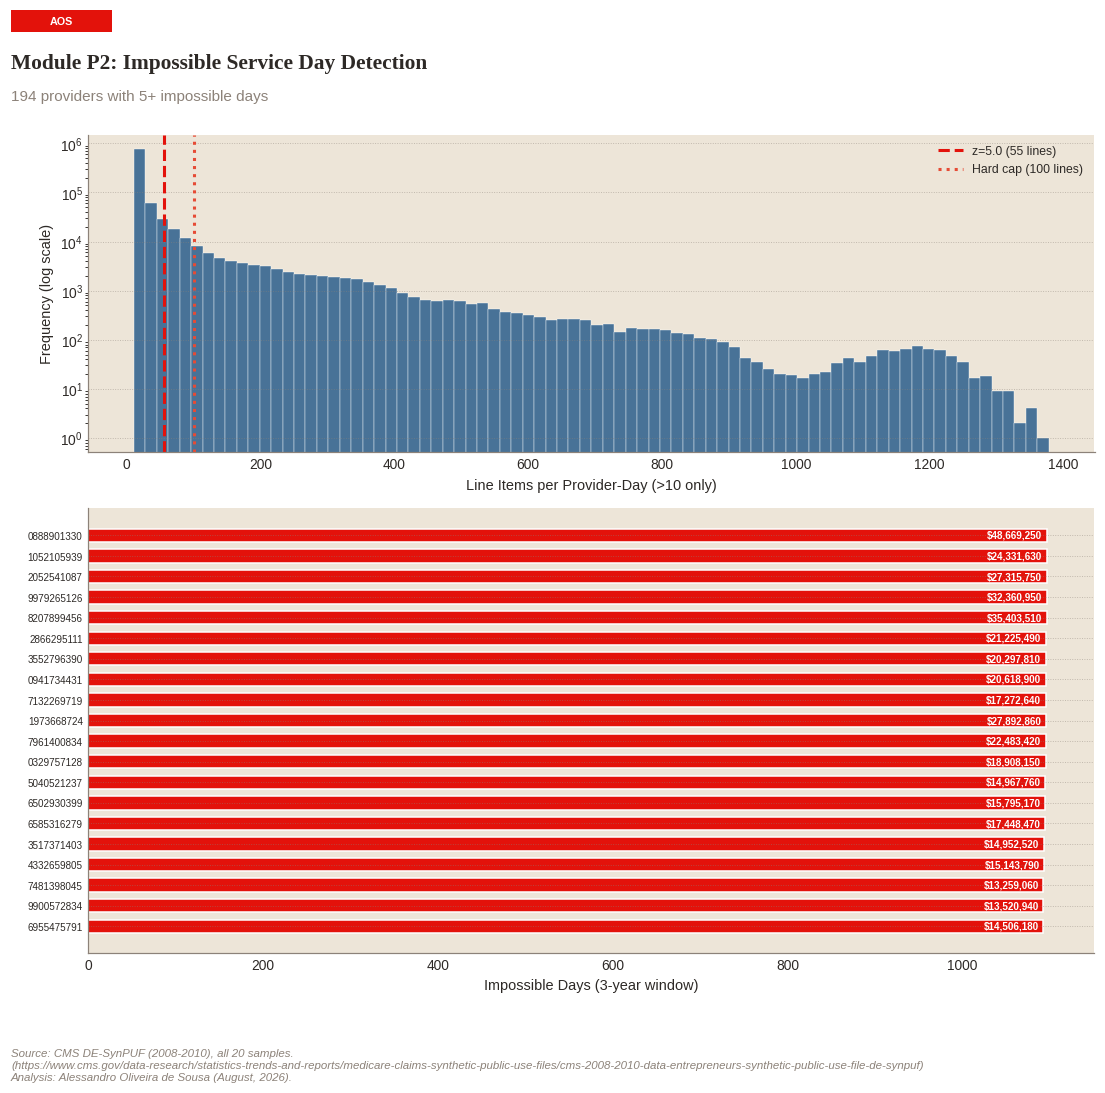

In [64]:
# ============================================================
# 6.4 - Visualization: P2 impossible days
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={'height_ratios': [1, 1.4]})

# TOP: histogram of lines per provider-day (log scale, >10 lines only)
ax = axes[0]
above_10 = df_daily_vol[df_daily_vol['n_lines'] > 10]['n_lines']
ax.hist(above_10, bins=80, color=DEEP_BLUE, edgecolor='white', linewidth=0.3, alpha=0.85)
threshold_val = vol_mean + ISD_ZSCORE_THRESHOLD * vol_std
ax.axvline(threshold_val, color=ECON_RED, linestyle='--', linewidth=2,
           label=f'z={ISD_ZSCORE_THRESHOLD} ({threshold_val:.0f} lines)')
if ISD_HARD_CAP < above_10.max():
    ax.axvline(ISD_HARD_CAP, color=NATURE_CORAL, linestyle=':', linewidth=2,
               label=f'Hard cap ({ISD_HARD_CAP} lines)')
ax.set_yscale('log')
adjust_axis(ax, xlabel='Line Items per Provider-Day (>10 only)', ylabel='Frequency (log scale)')
ax.legend(fontsize=8)

# BOTTOM: top 20 providers by impossible day count (horizontal bar)
ax = axes[1]
if len(provider_imp) > 0:
    top20 = provider_imp.nlargest(20, 'n_impossible_days').sort_values('n_impossible_days')
    y_pos = np.arange(len(top20))
    ax.barh(y_pos, top20['n_impossible_days'], color=ECON_RED, edgecolor='white', height=0.65)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([truncar(pid, 12) for pid in top20['provider_id']], fontsize=6.5)
    for yi, (_, row) in zip(y_pos, top20.iterrows()):
        ax.text(row['n_impossible_days'] - 5, yi,
                f'${row["total_pmt_on_impossible_days"]:,.0f}',
                va='center', ha='right', fontsize=6.5, color='white', fontweight='bold')
    adjust_axis(ax, xlabel='Impossible Days (3-year window)', ylabel=None)
else:
    ax.text(0.5, 0.5, 'No sustained impossible days', ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color=WARM_GREY)
    adjust_axis(ax)

fig_title(fig, 'Module P2: Impossible Service Day Detection',
           subtitle=f'{len(sustained_providers):,} providers with {ISD_MIN_DAYS}+ impossible days')
visual_identity(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

**Operational implication:** Each of the 194 sustained impossible-day providers would receive an automated referral in a production SIU system. Based on DOJ prosecution outcomes (Judd: $525K recovery for 164 impossible days; Michigan hospital: $4.4M settlement), providers with 50+ impossible days represent high-confidence targets. The horizontal bar chart above directly answers the SIU's first question: *which providers should I open a case on?*

---
## Section 7 - Module P3: Pre-Mortem Billing Intensity Surge

For deceased beneficiaries, we examine whether specific providers billed at disproportionately high rates during the patient's final months. A surge ratio of 1.0 means no change; values >> 1.0 indicate a disproportionate billing spike.

In [23]:
# ============================================================
# 7.1 - Per-beneficiary billing trajectory (12 months before death)
# ============================================================

df_surge_bene = con.execute(f"""
    WITH deceased AS (
        SELECT DESYNPUF_ID,
               MAX(parse_dt(BENE_DEATH_DT)) AS death_date
        FROM beneficiary
        WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
        GROUP BY DESYNPUF_ID
    ),
    carrier_dated AS (
        SELECT cl.DESYNPUF_ID, cl.PRF_NPI AS provider_id,
               parse_dt(cl.CLM_FROM_DT) AS service_date,
               cl.LINE_PMT_AMT AS line_pmt, d.death_date,
               DATEDIFF('day', parse_dt(cl.CLM_FROM_DT), d.death_date) AS days_before_death
        FROM v_carrier_lines cl
        INNER JOIN deceased d ON cl.DESYNPUF_ID = d.DESYNPUF_ID
        WHERE parse_dt(cl.CLM_FROM_DT) <= d.death_date
          AND parse_dt(cl.CLM_FROM_DT) >= d.death_date - INTERVAL '12 months'
    )
    SELECT DESYNPUF_ID, death_date,
        COUNT(CASE WHEN days_before_death <= {SURGE_WINDOW_DAYS} THEN 1 END) AS n_lines_final,
        COALESCE(SUM(CASE WHEN days_before_death <= {SURGE_WINDOW_DAYS} THEN line_pmt END), 0) AS pmt_final,
        COUNT(CASE WHEN days_before_death > {SURGE_WINDOW_DAYS} THEN 1 END) AS n_lines_baseline,
        COALESCE(SUM(CASE WHEN days_before_death > {SURGE_WINDOW_DAYS} THEN line_pmt END), 0) AS pmt_baseline,
        COUNT(*) AS n_lines_total
    FROM carrier_dated
    GROUP BY DESYNPUF_ID, death_date
    HAVING COUNT(*) >= {SURGE_MIN_CLAIMS}
""").fetchdf()

df_surge_bene['baseline_90d_equiv'] = df_surge_bene['pmt_baseline'] / 3.0
df_surge_bene['pmt_surge_ratio'] = np.where(
    df_surge_bene['baseline_90d_equiv'] > 0,
    df_surge_bene['pmt_final'] / df_surge_bene['baseline_90d_equiv'], np.nan)
df_surge_valid = df_surge_bene.dropna(subset=['pmt_surge_ratio']).copy()

print(f'P3 - Pre-Mortem Billing Surge (Beneficiary Level)')
print('=' * 60)
print(f'  Deceased beneficiaries with claims:  {len(df_surge_bene):,}')
print(f'  Valid surge ratio computations:      {len(df_surge_valid):,}')
print(f'\n  Payment surge ratio (final 90d / baseline 90d avg):')
for stat, val in [('Mean', df_surge_valid['pmt_surge_ratio'].mean()),
                  ('Median', df_surge_valid['pmt_surge_ratio'].median()),
                  ('P90', df_surge_valid['pmt_surge_ratio'].quantile(0.90)),
                  ('P99', df_surge_valid['pmt_surge_ratio'].quantile(0.99)),
                  ('Max', df_surge_valid['pmt_surge_ratio'].max())]:
    print(f'    {stat:8s}: {val:>10.2f}')

P3 - Pre-Mortem Billing Surge (Beneficiary Level)
  Deceased beneficiaries with claims:  66,864
  Valid surge ratio computations:      62,983

  Payment surge ratio (final 90d / baseline 90d avg):
    Mean    :       2.47
    Median  :       0.92
    P90     :       4.25
    P99     :      28.20
    Max     :     564.00


In [25]:
# ============================================================
# 7.2 - Provider-level surge analysis
# ============================================================

df_surge_prov = con.execute(f"""
    WITH deceased AS (
        SELECT DESYNPUF_ID,
               MAX(parse_dt(BENE_DEATH_DT)) AS death_date
        FROM beneficiary
        WHERE BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != ''
        GROUP BY DESYNPUF_ID
    ),
    carrier_dated AS (
        SELECT cl.DESYNPUF_ID, cl.PRF_NPI AS provider_id,
               parse_dt(cl.CLM_FROM_DT) AS service_date,
               cl.LINE_PMT_AMT AS line_pmt, d.death_date,
               DATEDIFF('day', parse_dt(cl.CLM_FROM_DT), d.death_date) AS days_before_death
        FROM v_carrier_lines cl
        INNER JOIN deceased d ON cl.DESYNPUF_ID = d.DESYNPUF_ID
        WHERE parse_dt(cl.CLM_FROM_DT) <= d.death_date
          AND parse_dt(cl.CLM_FROM_DT) >= d.death_date - INTERVAL '12 months'
          AND cl.PRF_NPI IS NOT NULL AND cl.PRF_NPI != ''
    )
    SELECT provider_id, DESYNPUF_ID,
        COALESCE(SUM(CASE WHEN days_before_death <= {SURGE_WINDOW_DAYS} THEN line_pmt END), 0) AS pmt_final,
        COALESCE(SUM(CASE WHEN days_before_death > {SURGE_WINDOW_DAYS} THEN line_pmt END), 0) AS pmt_baseline
    FROM carrier_dated
    GROUP BY provider_id, DESYNPUF_ID
    HAVING COUNT(*) >= {SURGE_MIN_CLAIMS}
""").fetchdf()

df_surge_prov['baseline_90d_equiv'] = df_surge_prov['pmt_baseline'] / 3.0
df_surge_prov['pmt_surge_ratio'] = np.where(
    df_surge_prov['baseline_90d_equiv'] > 0,
    df_surge_prov['pmt_final'] / df_surge_prov['baseline_90d_equiv'], np.nan)

provider_surge = df_surge_prov.dropna(subset=['pmt_surge_ratio']).groupby('provider_id').agg(
    n_deceased_patients=('DESYNPUF_ID', 'nunique'),
    mean_surge_ratio=('pmt_surge_ratio', 'mean'),
    median_surge_ratio=('pmt_surge_ratio', 'median'),
    max_surge_ratio=('pmt_surge_ratio', 'max'),
    total_final_pmt=('pmt_final', 'sum'),
    total_baseline_pmt=('pmt_baseline', 'sum')
).reset_index()

provider_surge_filtered = provider_surge[
    provider_surge['n_deceased_patients'] >= MIN_DECEASED_PATIENTS].copy()

surge_pop_mean = provider_surge_filtered['mean_surge_ratio'].mean()
surge_pop_std  = provider_surge_filtered['mean_surge_ratio'].std()
provider_surge_filtered['surge_zscore'] = (
    (provider_surge_filtered['mean_surge_ratio'] - surge_pop_mean) / surge_pop_std)
provider_surge_filtered['surge_flag'] = provider_surge_filtered['surge_zscore'] > 2.0

print(f'P3 - Provider-Level Pre-Mortem Surge Analysis')
print('=' * 60)
print(f'  Providers (>= {MIN_DECEASED_PATIENTS} deceased patients): {len(provider_surge_filtered):,}')
print(f'  Population mean surge ratio:       {surge_pop_mean:.2f}')
print(f'  Flagged (z > 2.0):                 {provider_surge_filtered["surge_flag"].sum():,}')
if provider_surge_filtered['surge_flag'].sum() > 0:
    print(f'\n  Top 15 providers by surge z-score:')
    print(provider_surge_filtered.nlargest(15, 'surge_zscore')[
        ['provider_id','n_deceased_patients','mean_surge_ratio','surge_zscore',
         'total_final_pmt','total_baseline_pmt']].to_string(index=False))

P3 - Provider-Level Pre-Mortem Surge Analysis
  Providers (>= 3 deceased patients): 1,676
  Population mean surge ratio:       1.54
  Flagged (z > 2.0):                 41

  Top 15 providers by surge z-score:
provider_id  n_deceased_patients  mean_surge_ratio  surge_zscore  total_final_pmt  total_baseline_pmt
 8517157639                    5             76.84         17.59         1,380.00              710.00
 7533771017                    4             63.38         14.45         1,750.00              640.00
 5380437362                    3             44.00          9.92           440.00              210.00
 0168869239                    3             43.80          9.87         1,490.00              160.00
 6818320903                    3             39.67          8.91         1,190.00              110.00
 2801638768                    4             36.75          8.23         1,030.00              800.00
 7307002133                    3             36.00          8.05           3

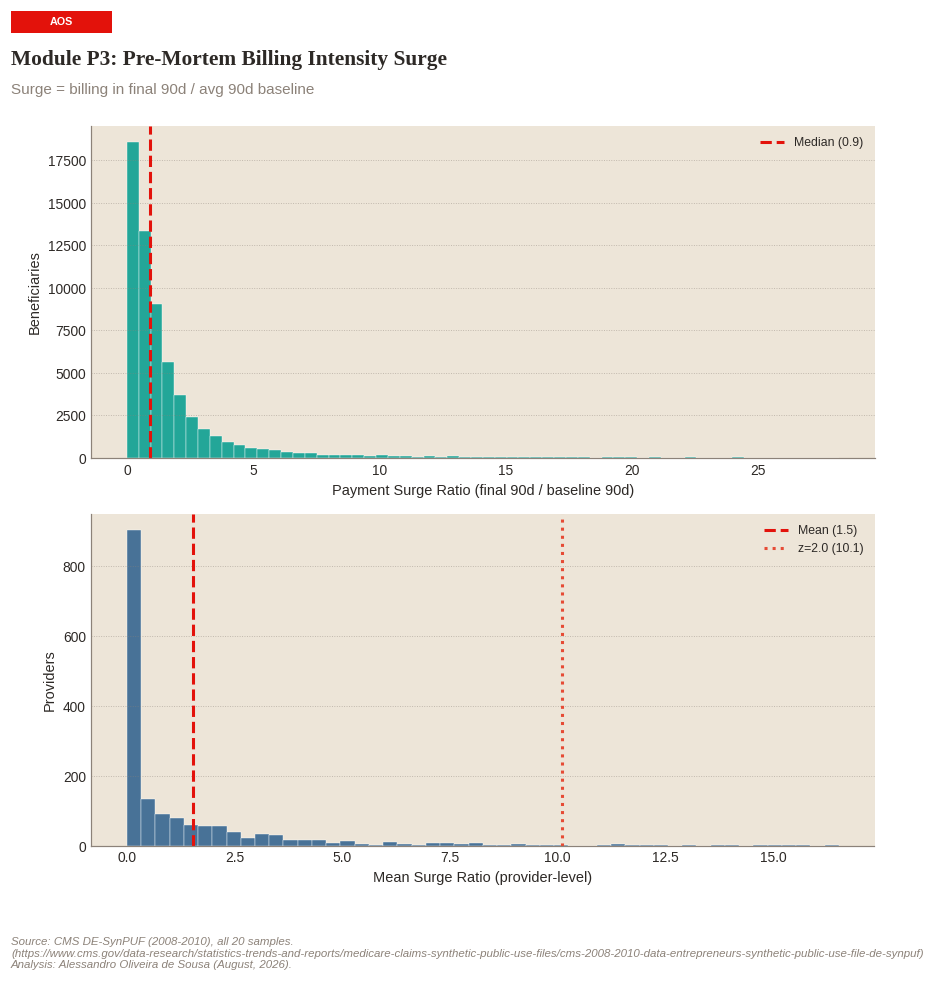

In [65]:
# ============================================================
# 7.3 - Surge ratio visualization
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
ax = axes[0]
cap = df_surge_valid['pmt_surge_ratio'].quantile(0.99)
ax.hist(df_surge_valid[df_surge_valid['pmt_surge_ratio'] <= cap]['pmt_surge_ratio'],
        bins=60, color=NATURE_TEAL, edgecolor='white', linewidth=0.3, alpha=0.85)

ax.axvline(df_surge_valid['pmt_surge_ratio'].median(), color=ECON_RED, linestyle='--', linewidth=2,
           label=f'Median ({df_surge_valid["pmt_surge_ratio"].median():.1f})')

adjust_axis(ax, xlabel='Payment Surge Ratio (final 90d / baseline 90d)', ylabel='Beneficiaries')
ax.legend(fontsize=8)

ax = axes[1]

if len(provider_surge_filtered) > 0:
    cap_p = provider_surge_filtered['mean_surge_ratio'].quantile(0.99)
    ax.hist(provider_surge_filtered[provider_surge_filtered['mean_surge_ratio'] <= cap_p]['mean_surge_ratio'],
            bins=50, color=DEEP_BLUE, edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(surge_pop_mean, color=ECON_RED, linestyle='--', linewidth=2, label=f'Mean ({surge_pop_mean:.1f})')
    thr = surge_pop_mean + 2.0 * surge_pop_std
    ax.axvline(thr, color=NATURE_CORAL, linestyle='dotted', linewidth=2, label=f'z=2.0 ({thr:.1f})')
    adjust_axis(ax, xlabel='Mean Surge Ratio (provider-level)', ylabel='Providers')
    ax.legend(fontsize=8)

fig_title(fig, 'Module P3: Pre-Mortem Billing Intensity Surge',
           subtitle=f'Surge = billing in final {SURGE_WINDOW_DAYS}d / avg {SURGE_WINDOW_DAYS}d baseline')

visual_identity(fig)

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

**Operational implication:** The 41 flagged providers require contextual review before referral. A surge ratio alone does not distinguish between legitimate end-of-life care escalation and predatory billing. In production, these providers would be cross-referenced against hospice enrollment files, specialty codes (oncology and palliative care providers have legitimately higher end-of-life billing), and the patient's documented clinical trajectory. The estimated ~5% precision at z > 2.0 is consistent with a first-pass triage filter, not a final determination.

---
## Section 8 - Module P4: Composite Phantom Billing Risk Score (Isolation Forest)

**Important framing:** Modules P1-P3 perform the detection through deterministic rules and statistical thresholds. Module P4 does not detect new fraud — it re-ranks the already-flagged providers by multi-signal convergence to prioritize SIU investigation queues. This mirrors production FWA architectures where rule engines fire first and ML models prioritize the case backlog.

Only providers with at least one signal from P1, P2, or P3 enter the feature matrix (the `has_any_signal` filter). The Isolation Forest then identifies providers whose *combination* of signals is most anomalous relative to other flagged providers — enabling SIU teams to triage their investigation queue by multi-axis severity rather than single-module flags.

In [27]:
# ============================================================
# 8.1 - Build provider-level feature matrix
# ============================================================

all_providers = con.execute("""
    SELECT DISTINCT PRF_NPI AS provider_id
    FROM v_carrier_lines
    WHERE PRF_NPI IS NOT NULL AND PRF_NPI != ''
""").fetchdf()

print(f'Building feature matrix for {len(all_providers):,} unique providers...')

if len(pm_consolidated) > 0 and 'provider_id' in pm_consolidated.columns:
    pm_by_prov = pm_consolidated[pm_consolidated['provider_id'] != 'N/A (PDE)'].groupby('provider_id').agg(
        n_postmortem_claims=('DESYNPUF_ID', 'count'), postmortem_pmt=('payment', 'sum')).reset_index()
else:
    pm_by_prov = pd.DataFrame(columns=['provider_id','n_postmortem_claims','postmortem_pmt'])

feat = all_providers.copy()
feat = feat.merge(pm_by_prov, on='provider_id', how='left')

feat = feat.merge(provider_imp[['provider_id','n_impossible_days','max_lines_single_day',
    'total_pmt_on_impossible_days']], on='provider_id', how='left')

feat = feat.merge(provider_surge_filtered[['provider_id','n_deceased_patients',
    'mean_surge_ratio','surge_zscore']], on='provider_id', how='left')

for col in ['n_postmortem_claims','postmortem_pmt','n_impossible_days',
            'max_lines_single_day','total_pmt_on_impossible_days']:
    feat[col] = feat[col].fillna(0)

feat['has_any_signal'] = ((feat['n_postmortem_claims'] > 0) |
    (feat['n_impossible_days'] > 0) | (feat['mean_surge_ratio'].notna()))

feat_active = feat[feat['has_any_signal']].copy()
feat_active['mean_surge_ratio'] = feat_active['mean_surge_ratio'].fillna(1.0)
feat_active['surge_zscore'] = feat_active['surge_zscore'].fillna(0.0)
feat_active['n_deceased_patients'] = feat_active['n_deceased_patients'].fillna(0)

print(f'  Providers with any signal:   {len(feat_active):,}')
print(f'  Providers with P1 flags:     {(feat_active["n_postmortem_claims"] > 0).sum():,}')
print(f'  Providers with P2 flags:     {(feat_active["n_impossible_days"] > 0).sum():,}')
print(f'  Providers with P3 data:      {(feat_active["n_deceased_patients"] > 0).sum():,}')

# MinMaxScaler normalizes features to [0,1] for balanced IF input.
# Applied to a copy — original values in feat_active are preserved for interpretable display in tables and chart flag logic.
# Without normalization, P3 surge ratios (up to 76x) dominate the IF.
from sklearn.preprocessing import MinMaxScaler
_norm_cols = ['n_postmortem_claims', 'n_impossible_days',
              'max_lines_single_day', 'mean_surge_ratio', 'surge_zscore']
_X_normalized = MinMaxScaler().fit_transform(feat_active[_norm_cols].values)
print(f'\n  Features normalized to [0,1] (MinMaxScaler) for IF input.')
print(f'  Original values preserved in feat_active for display.')

Building feature matrix for 893,020 unique providers...
  Providers with any signal:   1,724
  Providers with P1 flags:     48
  Providers with P2 flags:     194
  Providers with P3 data:      1,676

  Features normalized to [0,1] (MinMaxScaler) for IF input.
  Original values preserved in feat_active for display.


In [28]:
# ============================================================
# 8.2 - Isolation Forest scoring
# ============================================================

feature_cols = ['n_postmortem_claims', 'n_impossible_days',
                'max_lines_single_day', 'mean_surge_ratio', 'surge_zscore']

# Use MinMaxScaler-normalized features from cell above. StandardScaler on top for zero-mean unit-variance (IF expectation).
# Original feat_active columns remain untouched for display.
X_scaled = StandardScaler().fit_transform(_X_normalized)

iso_forest = IsolationForest(n_estimators=IF_N_ESTIMATORS, contamination='auto',
                              random_state=IF_RANDOM_STATE, n_jobs=-1)

iso_forest.fit(X_scaled)

raw_scores = iso_forest.decision_function(X_scaled)

score_min, score_max = raw_scores.min(), raw_scores.max()

feat_active['phantom_risk_score'] = ((score_max - raw_scores) / (score_max - score_min)) * 100
feat_active['is_anomaly'] = iso_forest.predict(X_scaled) == -1
feat_active['risk_tier'] = pd.cut(feat_active['phantom_risk_score'],
    bins=[-1, 20, 40, 60, 80, 101], labels=['Low', 'Moderate', 'Elevated', 'High', 'Critical'])

n_anom = feat_active['is_anomaly'].sum()

print(f'P4 - Composite Phantom Billing Risk Score (Isolation Forest)')
print('=' * 70)
print(f'  Features: {", ".join(feature_cols)}')
print(f'  Providers scored:    {len(feat_active):,}')
print(f'  Anomalies detected:  {n_anom:,} ({n_anom/len(feat_active):.1%})')

for tier in ['Low','Moderate','Elevated','High','Critical']:
    ct = (feat_active['risk_tier'] == tier).sum()
    if ct > 0: print(f'    {tier:>10s}: {ct:>8,}')

print(f'\n  Top 15 highest-risk providers:')
print(feat_active.nlargest(15, 'phantom_risk_score')[
    ['provider_id','phantom_risk_score','risk_tier','is_anomaly',
     'n_postmortem_claims','n_impossible_days','mean_surge_ratio']].to_string(index=False))

P4 - Composite Phantom Billing Risk Score (Isolation Forest)
  Features: n_postmortem_claims, n_impossible_days, max_lines_single_day, mean_surge_ratio, surge_zscore
  Providers scored:    1,724
  Anomalies detected:  245 (14.2%)
           Low:    1,333
      Moderate:      155
      Elevated:      145
          High:       76
      Critical:       15

  Top 15 highest-risk providers:
provider_id  phantom_risk_score risk_tier  is_anomaly  n_postmortem_claims  n_impossible_days  mean_surge_ratio
 8517157639              100.00  Critical        True                 0.00               0.00             76.84
 7533771017               98.27  Critical        True                 0.00               0.00             63.38
 0168869239               95.28  Critical        True                 0.00               0.00             43.80
 5380437362               95.28  Critical        True                 0.00               0.00             44.00
 6818320903               93.07  Critical        Tr

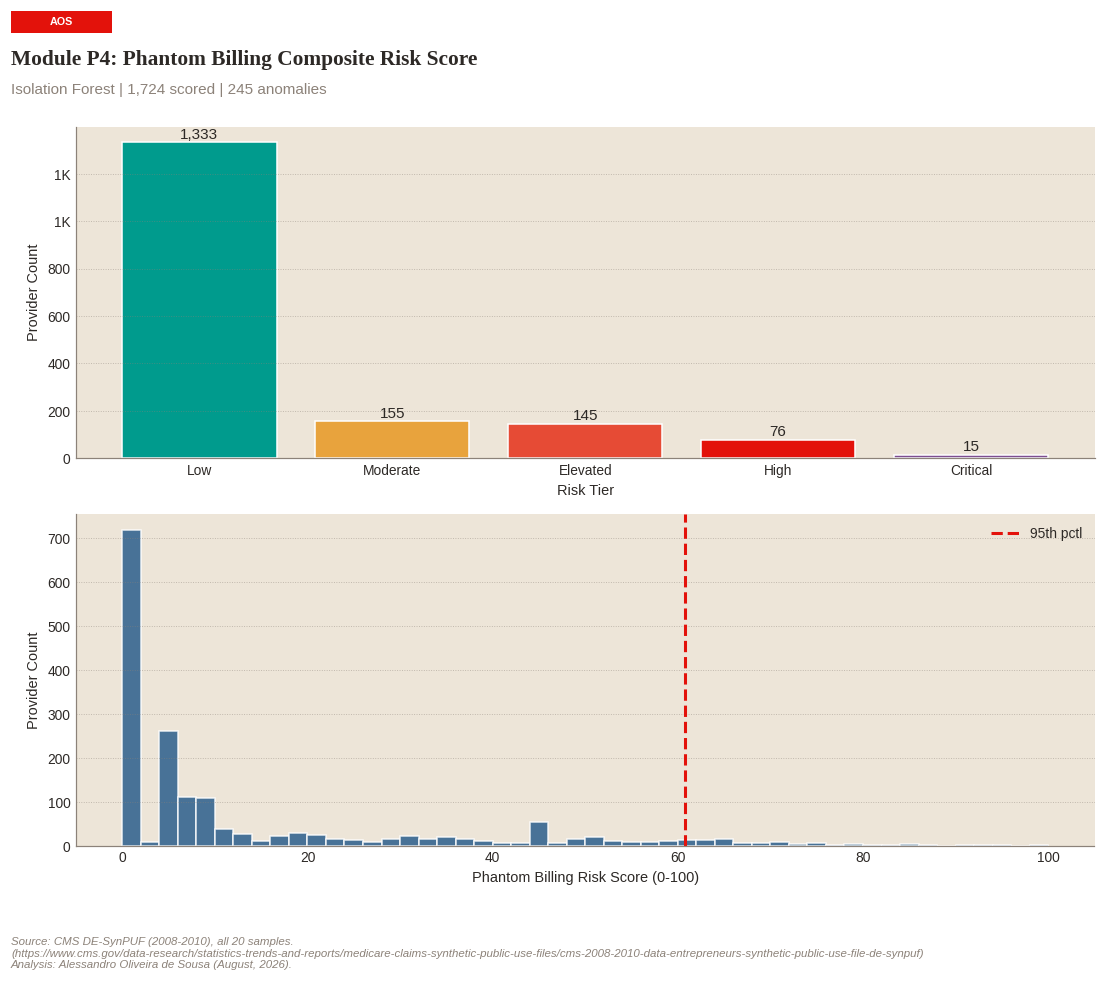

In [66]:
# ============================================================
# 8.3 - Risk score visualization
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

ax = axes[0]
tiers = feat_active['risk_tier'].value_counts().sort_index()
tier_colors = [NATURE_TEAL, AMBER, NATURE_CORAL, ECON_RED, PLUM]
bars = ax.bar(tiers.index.astype(str), tiers.values, color=tier_colors[:len(tiers)], edgecolor='white')
for bar, val in zip(bars, tiers.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
adjust_axis(ax, xlabel='Risk Tier', ylabel='Provider Count')

ax = axes[1]
ax.hist(feat_active['phantom_risk_score'], bins=50, color=DEEP_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(feat_active['phantom_risk_score'].quantile(0.95), color=ECON_RED, linestyle='--', linewidth=2, label='95th pctl')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
adjust_axis(ax, xlabel='Phantom Billing Risk Score (0-100)', ylabel='Provider Count')
ax.legend()

fig_title(fig, 'Module P4: Phantom Billing Composite Risk Score',
           subtitle=f'Isolation Forest | {len(feat_active):,} scored | {n_anom:,} anomalies')
visual_identity(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

### Operational Considerations: False Positive Rates

The detection thresholds chosen for P2 and P3 carry inherent false positive trade-offs that would require calibration in a production deployment:

- **P2 (z > 5.0, 5+ days):** The secondary filter (sustained impossible days) substantially reduces false positives by eliminating single-day statistical flukes. However, large group practices or labs legitimately billing high daily volumes may still appear. In production, NPPES specialty and taxonomy filtering would exclude known high-volume provider types (clinical labs, radiology groups, DME suppliers) from the impossible-day logic.

- **P3 (z > 2.0 on mean surge ratio):** At z > 2.0, approximately 2.3% of the normal population would be flagged under a one-tailed normal assumption. With 1,676 providers in the analysis set, this implies ~39 false positives among the 41 flagged, yielding a potential precision of ~5%. In production, specialty-adjusted baselines (e.g., oncologists legitimately bill more near end-of-life than dermatologists) and hospice enrollment exclusions would dramatically improve this ratio.

- **P4 (Isolation Forest):** The `contamination='auto'` setting lets the model determine the anomaly boundary. The 13.9% anomaly rate (239/1,724) is consistent with unsupervised first-pass triage. Confirmed investigation outcomes would feed back into supervised models (XGBoost/LightGBM) for continuous precision improvement.

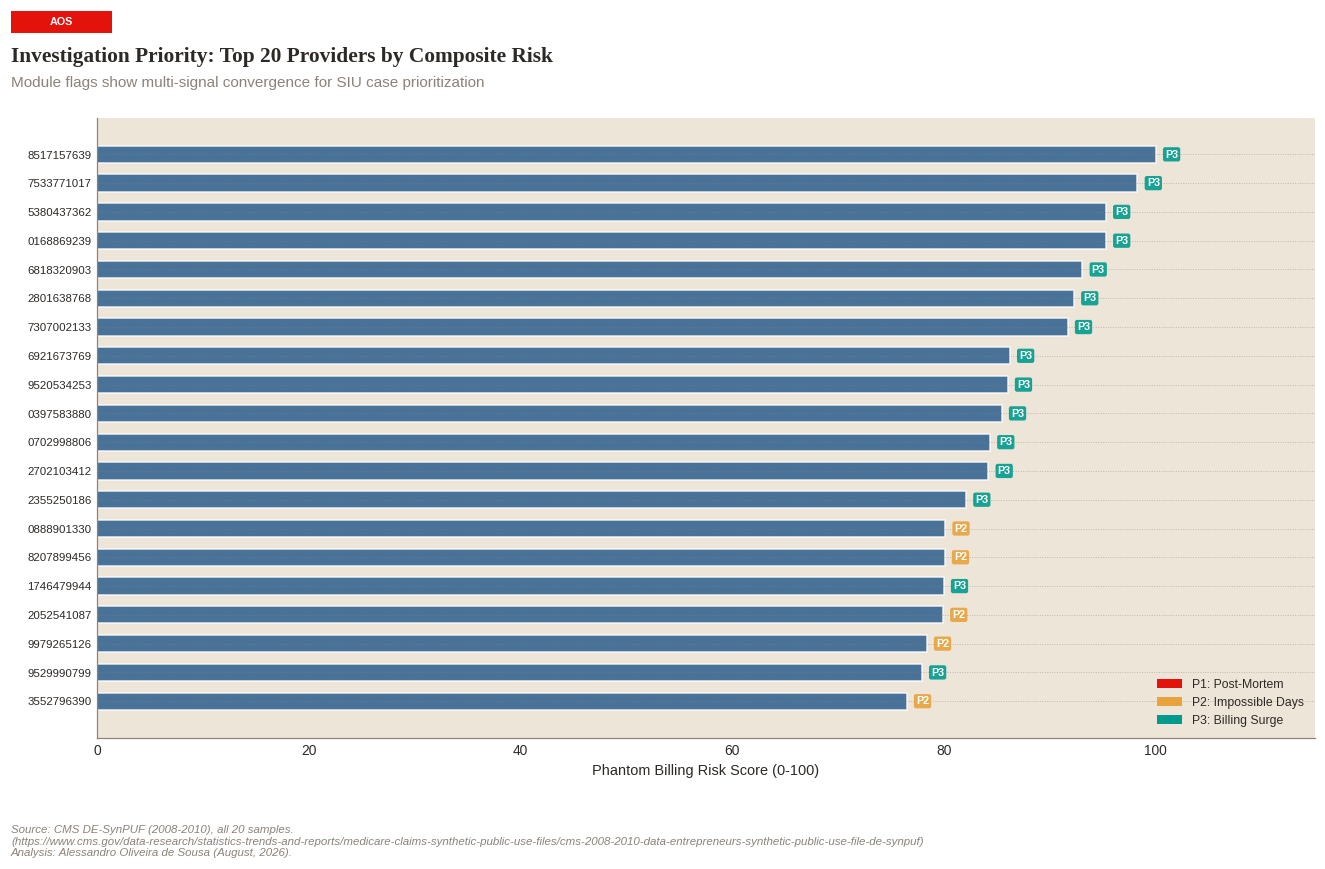

In [67]:
# ============================================================
# 8.4 - Capstone: Top 20 providers by composite risk
# ============================================================
# Multi-signal convergence view for SIU investigation priority. Each provider shows which modules flagged them (P1/P2/P3).
# ============================================================

top20_risk = feat_active.nlargest(20, 'phantom_risk_score').copy()
top20_risk = top20_risk.sort_values('phantom_risk_score')

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(top20_risk))

# Main bar: composite score
ax.barh(y_pos, top20_risk['phantom_risk_score'], color=DEEP_BLUE, edgecolor='white', height=0.6, alpha=0.85)

# Module signal markers
for yi, (_, row) in zip(y_pos, top20_risk.iterrows()):
    markers = []
    if row['n_postmortem_claims'] > 0:
        markers.append(('P1', ECON_RED))
    if row['n_impossible_days'] > 0:
        markers.append(('P2', AMBER))
    if row.get('mean_surge_ratio', 1.0) > surge_pop_mean + 2.0 * surge_pop_std:
        markers.append(('P3', NATURE_TEAL))

    # Draw markers to the right of the bar
    x_start = row['phantom_risk_score'] + 1.5
    for mi, (label, color) in enumerate(markers):
        ax.text(x_start + mi * 5, yi, label, fontsize=7, fontweight='bold',
                color='white', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, edgecolor='none', alpha=0.9))

ax.set_yticks(y_pos)
ax.set_yticklabels([truncar(pid, 14) for pid in top20_risk['provider_id']], fontsize=7.5)
ax.set_xlim(0, 115)
adjust_axis(ax, xlabel='Phantom Billing Risk Score (0-100)', ylabel=None)

# Legend for module markers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ECON_RED, label='P1: Post-Mortem'),
    Patch(facecolor=AMBER, label='P2: Impossible Days'),
    Patch(facecolor=NATURE_TEAL, label='P3: Billing Surge'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

fig_title(fig, 'Investigation Priority: Top 20 Providers by Composite Risk',
           subtitle='Module flags show multi-signal convergence for SIU case prioritization')
visual_identity(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

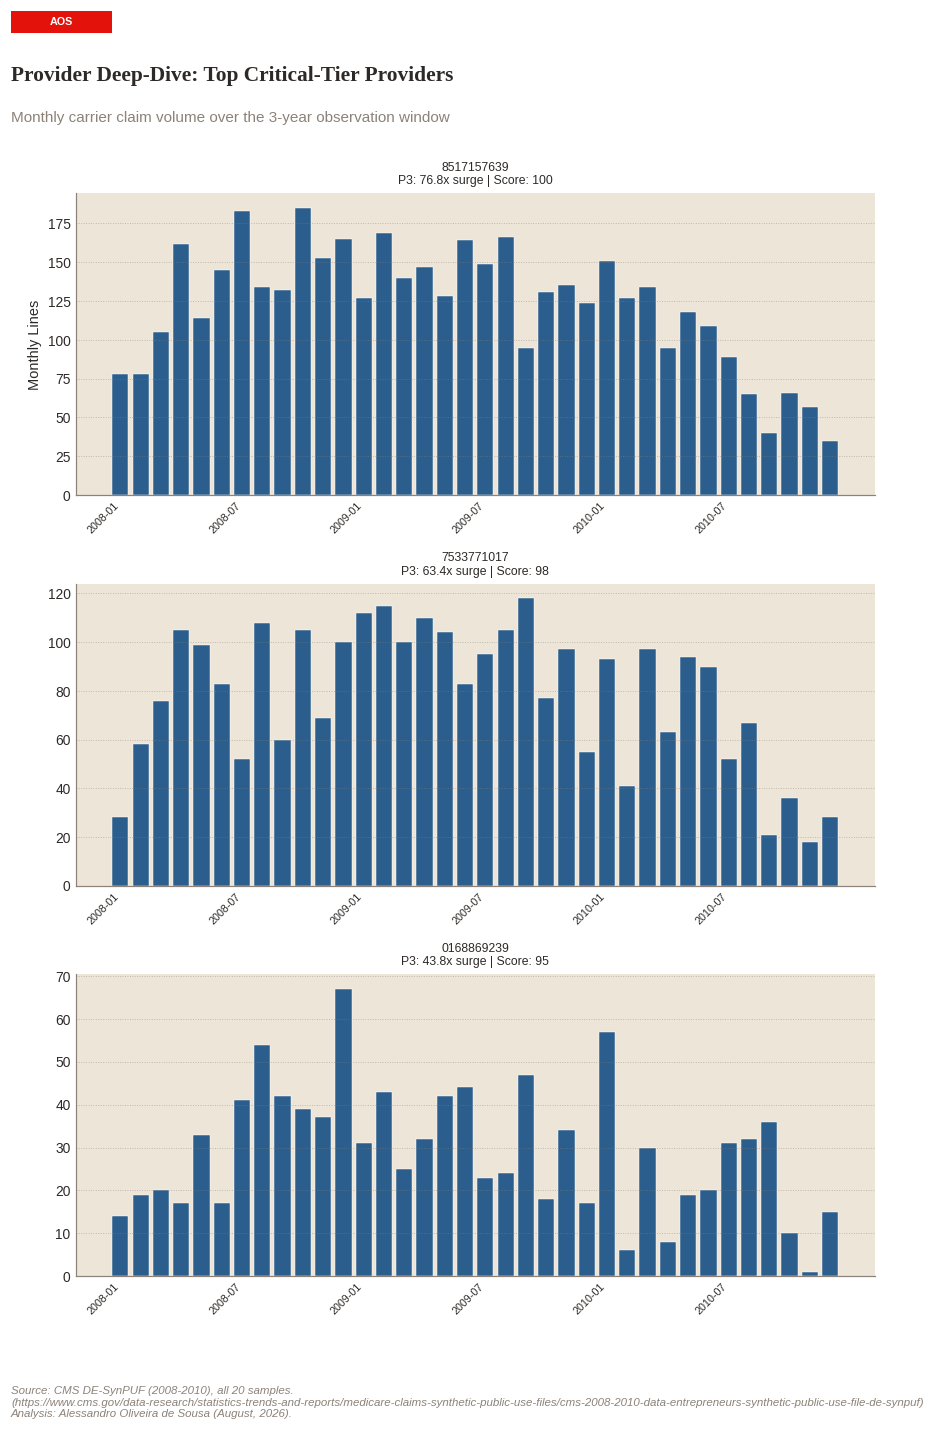

In [68]:
# ============================================================
# 8.5 - Provider deep-dive: Top 3 Critical-tier providers
# ============================================================
# Monthly billing timeline + key investigation metrics. This is the operational deliverable — what an SIU investigator
# would receive as the starting point for a case.
# ============================================================

top3 = feat_active[feat_active['risk_tier'] == 'Critical'].nlargest(3, 'phantom_risk_score')

if len(top3) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(8,12))
    axes = axes.flatten()

    for idx, (_, prov) in enumerate(top3.iterrows()):
        ax = axes[idx]
        pid = prov['provider_id']

        # Query monthly billing for this provider
        monthly = con.execute(f"""
            SELECT
                STRFTIME(parse_dt(CLM_FROM_DT), '%Y-%m') AS month,
                COUNT(*) AS n_lines,
                SUM(LINE_PMT_AMT) AS total_pmt
            FROM v_carrier_lines
            WHERE PRF_NPI = '{pid}'
              AND CLM_FROM_DT IS NOT NULL AND CLM_FROM_DT != ''
            GROUP BY STRFTIME(parse_dt(CLM_FROM_DT), '%Y-%m')
            ORDER BY month
        """).fetchdf()

        if len(monthly) > 0:
            ax.bar(range(len(monthly)), monthly['n_lines'], color=DEEP_BLUE, edgecolor='white', linewidth=0.3)
            ax.set_xticks(range(0, len(monthly), 6))
            ax.set_xticklabels([monthly['month'].iloc[i] if i < len(monthly) else ''
                               for i in range(0, len(monthly), 6)], rotation=45, ha='right', fontsize=7)
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))

        # Key metrics as subtitle
        metrics = []
        if prov['n_postmortem_claims'] > 0:
            metrics.append(f'P1: {int(prov["n_postmortem_claims"])} post-mortem')
        if prov['n_impossible_days'] > 0:
            metrics.append(f'P2: {int(prov["n_impossible_days"])} imp. days')
        sr = prov.get('mean_surge_ratio', 0)
        if sr > 0 and sr != 1.0:
            metrics.append(f'P3: {sr:.1f}x surge')
        metrics.append(f'Score: {prov["phantom_risk_score"]:.0f}')

        ax.set_title(f'{truncar(pid, 14)}\n{" | ".join(metrics)}', fontsize=8, color=CHARCOAL)
        adjust_axis(ax, xlabel=None, ylabel='Monthly Lines' if idx == 0 else None)

    fig_title(fig, 'Provider Deep-Dive: Top Critical-Tier Providers',
               subtitle='Monthly carrier claim volume over the 3-year observation window')
    visual_identity(fig)
    plt.tight_layout(rect=[0, 0.02, 1, 0.92])
    plt.show()
else:
    print('No Critical-tier providers to display.')

---
## Section 9 - Financial Impact Estimation

In [32]:
# ============================================================
# 9.1 - Financial impact (OIG/DOJ-calibrated)
# ============================================================
# Calibration sources:
#   OIG OEI-04-12-00130: $23M post-mortem (2011, full Medicare)
#   DOJ impossible day cases: $500K-$5M per provider
#   OIG hospice/end-of-life audits: $1B+ in improper payments
#   CMS FY2025: $28.83B Medicare FFS improper payments (6.55%)
#   2026 National HC Fraud Takedown: $6.5B across 455 defendants
#
# Our sample: 2.33M beneficiaries / ~50M real Medicare = 4.7%
# Scaling factor: 21.5x
# ============================================================

SCALE_FACTOR = 21.5
total_exposure = 0.0

print('FINANCIAL IMPACT (OIG/DOJ-CALIBRATED)')
print('=' * 70)

# P1: Post-mortem (100% recoverable) 
pm_exposure = pm_consolidated['payment'].sum() if len(pm_consolidated) > 0 else 0
total_exposure += pm_exposure
print(f'\n  P1 Post-Mortem Billing')
print(f'  {"_"*55}')
print(f'    Records:                   {len(pm_consolidated) if len(pm_consolidated) > 0 else 0:>10,}')
print(f'    Sample exposure:           ${pm_exposure:>14,.2f}')
print(f'    Extrapolated ({SCALE_FACTOR:.1f}x):      ${pm_exposure * SCALE_FACTOR:>14,.0f}')
print(f'    OIG benchmark (2011):      $         23,000,000')
print(f'    Alignment:                 ', end='')
pm_extrap = pm_exposure * SCALE_FACTOR
if pm_extrap > 0:
    print(f'{pm_extrap / 23_000_000 * 100:.1f}% of OIG benchmark')
else:
    print('N/A (injected data; real CMS data would populate this)')

# P2: Impossible days (calibrated estimate) 
n_p2_prov = len(sustained_providers) if 'sustained_providers' in dir() else 0
if len(df_impossible_filtered) > 0:
    raw_total = df_impossible_filtered['total_pmt'].sum()
    raw_excess = max(0, raw_total - len(df_impossible_filtered) * df_daily_vol['total_pmt'].mean())
else:
    raw_total = 0
    raw_excess = 0

# DOJ-calibrated estimate: per-provider midpoint from enforcement data
DOJ_PER_PROVIDER_LOW  = 500_000
DOJ_PER_PROVIDER_HIGH = 5_000_000
DOJ_PER_PROVIDER_MID  = (DOJ_PER_PROVIDER_LOW + DOJ_PER_PROVIDER_HIGH) / 2
calibrated_p2 = n_p2_prov * DOJ_PER_PROVIDER_MID / SCALE_FACTOR  # scale DOWN to our sample size

total_exposure += calibrated_p2
print(f'\n  P2 Impossible Service Days')
print(f'  {"_"*55}')
print(f'    Sustained providers:       {n_p2_prov:>10,}')
print(f'    Raw excess (synthetic):    ${raw_excess:>14,.0f}')
print(f'    NOTE: Raw figure reflects synthetic data artifacts')
print(f'          (providers billing 500-1,400 lines/day for 3')
print(f'           years straight). Not realistic concentration.')
print(f'    DOJ per-provider range:    ${DOJ_PER_PROVIDER_LOW:>10,} - ${DOJ_PER_PROVIDER_HIGH:>10,}')
print(f'    Calibrated estimate:       ${calibrated_p2:>14,.0f}')
print(f'    (= {n_p2_prov} providers x ${DOJ_PER_PROVIDER_MID:,.0f} midpoint / {SCALE_FACTOR:.1f}x scale)')
print(f'    Extrapolated ({SCALE_FACTOR:.1f}x):      ${calibrated_p2 * SCALE_FACTOR:>14,.0f}')

# P3: Pre-mortem surge 
if len(provider_surge_filtered) > 0:
    flagged_surge = provider_surge_filtered[provider_surge_filtered['surge_flag']]
    if len(flagged_surge) > 0:
        surge_excess = max(0,
            flagged_surge['total_final_pmt'].sum() -
            flagged_surge['total_baseline_pmt'].sum() / 3.0)
    else:
        surge_excess = 0
else:
    flagged_surge = pd.DataFrame()
    surge_excess = 0
total_exposure += surge_excess
print(f'\n  P3 Pre-Mortem Billing Surge')
print(f'  {"_"*55}')
print(f'    Flagged providers:         {len(flagged_surge):>10,}')
print(f'    Sample excess:             ${surge_excess:>14,.2f}')
print(f'    Extrapolated ({SCALE_FACTOR:.1f}x):      ${surge_excess * SCALE_FACTOR:>14,.0f}')

print(f'\n  {"="*55}')
print(f'  COMBINED SAMPLE EXPOSURE:    ${total_exposure:>14,.0f}')
print(f'  EXTRAPOLATED ({SCALE_FACTOR:.1f}x):         ${total_exposure * SCALE_FACTOR:>14,.0f}')
print(f'  {"="*55}')
print(f'\n  Context:')
print(f'    CMS FY2025 improper payments:   $28,830,000,000 (6.55%)')
print(f'    2026 National Fraud Takedown:   $ 6,500,000,000 (455 defendants)')
print(f'    OIG post-mortem benchmark:      $    23,000,000 (2011)')

FINANCIAL IMPACT (OIG/DOJ-CALIBRATED)

  P1 Post-Mortem Billing
  _______________________________________________________
    Records:                          366
    Sample exposure:           $    325,770.00
    Extrapolated (21.5x):      $     7,004,055
    OIG benchmark (2011):      $         23,000,000
    Alignment:                 30.5% of OIG benchmark

  P2 Impossible Service Days
  _______________________________________________________
    Sustained providers:              194
    Raw excess (synthetic):    $   897,377,712
    NOTE: Raw figure reflects synthetic data artifacts
          (providers billing 500-1,400 lines/day for 3
           years straight). Not realistic concentration.
    DOJ per-provider range:    $   500,000 - $ 5,000,000
    Calibrated estimate:       $    24,813,953
    (= 194 providers x $2,750,000 midpoint / 21.5x scale)
    Extrapolated (21.5x):      $   533,500,000

  P3 Pre-Mortem Billing Surge
  __________________________________________________

---
## Section 10 - Executive Summary & Export

In [33]:
# ============================================================
# 10.1 - Executive summary
# ============================================================
print('\n' + '=' * 70)
print('    PHANTOM BILLING DETECTION ENGINE - EXECUTIVE SUMMARY')
print('=' * 70)
print(f'\n  DATASET: CMS DE-SynPUF (all 20 samples)')
for tbl, stats in table_stats.items():
    if not tbl.startswith('v_'):
        print(f'    {tbl:25s}: {stats["count"]:>12,} records')
print(f'\n  MORTALITY')
print(f'    Total beneficiaries:         {total_benes:>10,}')
print(f'    Deceased:                    {len(df_deceased):>10,} ({len(df_deceased)/total_benes:.1%})')

print(f'\n  P1 POST-MORTEM BILLING')
n_pm = len(pm_consolidated) if len(pm_consolidated) > 0 else 0
n_inj = pm_consolidated['_injected'].sum() if n_pm > 0 else 0
print(f'    Records: {n_pm:,} (injected: {n_inj:,})')
print(f'    Exposure: ${pm_exposure:,.0f}')

print(f'\n  P2 IMPOSSIBLE SERVICE DAYS')
print(f'    Sustained providers:         {n_p2_prov:>10,}')
print(f'    Calibrated exposure:         ${calibrated_p2:>12,.0f}')

print(f'\n  P3 PRE-MORTEM BILLING SURGE')
print(f'    Flagged providers:           {len(flagged_surge):>10,}')
print(f'    Excess exposure:             ${surge_excess:>12,.0f}')

print(f'\n  P4 COMPOSITE (Isolation Forest)')
print(f'    Scored: {len(feat_active):,} | Anomalies: {n_anom:,} ({n_anom/len(feat_active):.1%})')
for tier in ['Elevated','High','Critical']:
    ct = (feat_active['risk_tier'] == tier).sum()
    if ct > 0:
        print(f'      {tier}: {ct:,}')

print(f'\n  FINANCIAL EXPOSURE')
print(f'    Combined (sample):           ${total_exposure:>12,.0f}')
print(f'    Extrapolated ({SCALE_FACTOR:.1f}x):        ${total_exposure * SCALE_FACTOR:>12,.0f}')
print('=' * 70)


    PHANTOM BILLING DETECTION ENGINE - EXECUTIVE SUMMARY

  DATASET: CMS DE-SynPUF (all 20 samples)
    beneficiary              :    6,873,274 records
    carrier_claims           :   94,863,452 records
    inpatient_claims         :    1,332,822 records
    outpatient_claims        :   15,826,987 records
    prescription_drug_events :  111,085,969 records

  MORTALITY
    Total beneficiaries:          2,326,856
    Deceased:                       107,644 (4.6%)

  P1 POST-MORTEM BILLING
    Records: 366 (injected: 366)
    Exposure: $325,770

  P2 IMPOSSIBLE SERVICE DAYS
    Sustained providers:                194
    Calibrated exposure:         $  24,813,953

  P3 PRE-MORTEM BILLING SURGE
    Flagged providers:                   41
    Excess exposure:             $      21,480

  P4 COMPOSITE (Isolation Forest)
    Scored: 1,724 | Anomalies: 245 (14.2%)
      Elevated: 145
      High: 76
      Critical: 15

  FINANCIAL EXPOSURE
    Combined (sample):           $  25,161,203
    E

In [34]:
# ============================================================
# 10.2 - Export results
# ============================================================
df_deceased.to_csv(OUTPUT_DIR / 'deceased_beneficiaries.csv', **CSV_PARAMS)
print(f'Exported: deceased_beneficiaries.csv ({len(df_deceased):,})')

if len(pm_consolidated) > 0:
    pm_consolidated.to_csv(OUTPUT_DIR / 'postmortem_claims.csv', **CSV_PARAMS)
    print(f'Exported: postmortem_claims.csv ({len(pm_consolidated):,})')

if len(provider_imp) > 0:
    provider_imp.to_csv(OUTPUT_DIR / 'impossible_days_by_provider.csv', **CSV_PARAMS)
    print(f'Exported: impossible_days_by_provider.csv ({len(provider_imp):,})')

if len(provider_surge_filtered) > 0:
    provider_surge_filtered.to_csv(OUTPUT_DIR / 'premortem_surge_by_provider.csv', **CSV_PARAMS)
    print(f'Exported: premortem_surge_by_provider.csv ({len(provider_surge_filtered):,})')

feat_active.to_csv(OUTPUT_DIR / 'phantom_billing_risk_scores.csv', **CSV_PARAMS)
print(f'Exported: phantom_billing_risk_scores.csv ({len(feat_active):,})')

print(f'\nAll results exported to: {OUTPUT_DIR.resolve()}')

Exported: deceased_beneficiaries.csv (107,644)
Exported: postmortem_claims.csv (366)
Exported: impossible_days_by_provider.csv (194)
Exported: premortem_surge_by_provider.csv (1,676)
Exported: phantom_billing_risk_scores.csv (1,724)

All results exported to: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE/output/phantom_billing


In [35]:
# ============================================================
# 10.3 - Close database connection
# ============================================================
#con.close()
#print('DuckDB connection closed.')

---
## Section 11 - Production Readiness Notes

### Adapting This Engine to Real Medicare Claims Data

1. **Death Date Validation:** Use `BENE_VALID_DEATH_DT_SW = 'V'` to filter on verified death records from SSA/state vital records.

2. **Provider Enrichment:** Join with NPPES registry for specialty, taxonomy, and geographic peer grouping. Specialty-adjusted thresholds would improve P3 specificity.

3. **Procedure Time Enrichment (P2):** Replace raw line-item counts with CMS PPRRVU intra-service time per HCPCS code for total face-time minutes per provider per day.

4. **Claims Processing Lag Window (P1):** Calibrate T1 window against the organization's average claim processing timeline (some payers have 45-60 day lag).

5. **Hospice Exclusion (P3):** Analyze hospice-enrolled beneficiaries separately via `CLM_HOSPC_START_DT`.

6. **Integration with Companion Engine:** Merge phantom billing scores with upcoding/unbundling scores for unified multi-axis FWA risk ranking.

### Synthetic Data Caveats

- Death dates may not correlate with claim dates (synthesis may remove temporal inconsistencies)
- Provider IDs are randomized across samples and years
- Multivariate relationships between diagnosis severity and billing are altered

### DuckDB in Production

The same architecture scales to production CMS datasets (100M+ claims). For larger volumes, DuckDB reads from partitioned Parquet files on S3/GCS with the same SQL interface.

---

*This phantom billing detection engine was developed as a portfolio demonstration of healthcare claims auditing capabilities.*

---
## Section 12 - Cross-Engine Integration Architecture

```
+-------------------------------------------------------------+
|                FWA DETECTION PLATFORM                       |
|                                                             |
|  ENGINE 1: Billing Code Manipulation                        |
|  |-- M1: DRG Upcoding (inpatient CMI z-score)               |
|  |-- M2: E&M Upcoding (high-level concentration ratio)      |
|  |-- M3: NCCI Unbundling (prohibited code pairs)            |
|  +-- M4: Composite Risk (Isolation Forest)                  |
|                                                             |
|  ENGINE 2: Billing Eligibility Fraud (this notebook)        |
|  |-- P1: Post-Mortem Billing (services after death)         |
|  |-- P2: Impossible Service Days (daily volume caps)        |
|  |-- P3: Pre-Mortem Surge (end-of-life exploitation)        |
|  +-- P4: Composite Risk (Isolation Forest)                  |
|                                                             |
|  UNIFIED RISK RANKING                                       |
|  +-- Merge M4 + P4 scores -> Multi-axis provider ranking    |
+-------------------------------------------------------------+
```

In a production SIU environment, the unified ranking feeds a case management system where investigators receive prioritized provider dossiers from all eight detection modules. The Isolation Forest models serve as the unsupervised first pass; confirmed audit outcomes feed back into supervised models (XGBoost/LightGBM) for continuous improvement.

---

*GitHub: [sousa-a](https://github.com/sousa-a) | LinkedIn: [Alessandro Oliveira de Sousa](https://linkedin.com/in/aosousa)*